# CashLog - Designing the optimal Cash-Center Network



# The problem

CashLog is the Spanish market leader in cash logistics. Concretely it does three things: 
- collect cash from customers
- counts, stores and stores it in high-security Cash-Centers
- distributes cash back out to different customers

Historically CashLog ran one Cash Center in every Spanish provincial capital, because the central bank had a branch there. That reason is now gone, and two pressures now push the other way:

- Cash is shrinking. Electronic payment keeps replacing physical cash, so the
  volume each center handles is falling.
- Cash Centers are expensive. Security, surveillance and insurance make every
  single building cost millions of euros per year just to keep open.

Today the network is **42 Cash Centers** serving about **42,000 customer
locations**. The 42,000 customers have already been grouped into*515 customer regions.

> **The decision:** Out of the 42 existing Cash Centers, which
> subset do we **keep open** and which do we **close**, so that the **total yearly
> cost is minimal** while **every one of the 515 regions is still served**?

**Two hard constraints from the business side:**

1. We do not open new locations. We only choose among the 42 that exist.

2. Every region must remain served. Closing a center is only allowed if its
   regions can be picked up by other centers.

## 1. Formalizing the Problem

### Underlying Trade-off

We cannot just close the expensive centers, because there is an underlying trade-off that drives our decision problem:

If we open more centers, we will lower driving time/distance so we reduce transport cost, but have high fixed costs for running the Cash-Center
If we open fewer centers, we have low fixed costs but longer distances, so transport costs increase. 

The cheapest, most stable and most optimal network sits somewhere in the middle.

### Why optimizing the network as a whole matters

Scoring each Center individually and closing the worst one is not possible because of network effects. Wether a Center is worth keeping depends on which other centers are open. If one Center is closed, its regions have to be reasssigned to different Centers, which changes their loads and costs parameters. 

The Regions are interdependent, so we must decide all of them simultaneously by using a optimization model. 

### Starting point. Warehouse-location model

The classic template for "which facilities should we keep open" is the Warehouse-Location model. 

**The vocabulary**

| Symbol | Meaning |
|---|---|
| $i$ | a Cash Center (one of the 42), the "warehouse" |
| $j$ | a customer region (one of the 515) |
| $f_i$ | yearly fixed cost of running center $i$ |
| $c_{ij}$ | yearly transport cost of serving region $j$ from center $i$ |
| $y_i \in \{0,1\}$ | **decision:** is center $i$ open (1) or closed (0)? |
| $x_{ij} \in \{0,1\}$ | **decision:** is region $j$ served by center $i$? |

**The model:**

$$\min_{x,y}\; \underbrace{\sum_{i}\sum_{j} x_{ij}\,c_{ij}}_{\text{transport cost}}
\;+\; \underbrace{\sum_{i} f_i\,y_i}_{\text{fixed cost of open centers}}$$

subject to

$$\sum_{i} x_{ij} = 1 \;\;\forall j \quad\text{(every region served by exactly one center)}$$
$$x_{ij} \le y_i \;\;\forall i,j \quad\text{(you may only use a center that is open)}$$

This model is our starting point for the logic. But important core assumptions of this model do not apply for CashLog.

#### How the models breaks 

Three of the models build in assumptions cannot be applied to our CashLog Problem: 

1. $c_{ij}$ has no obvious value
The model assumes a known cost-per-link $c_{ij}$ exists. We do not have a "cost to serve region $j$ from center $i$" price tag in the raw data. Trucks
serve many customers per 8-hour shift on a route, not one round trip per
customer. We must therefore derive $c_{ij}$ from shift logic 

2. individual customers is the wrong unit of analysis
The model assumes a manageable, fixed set of "customers" $j$. Optimising location
choices against 42,000 individual points is computationally unpractical and not how real life routing logic works (Trucks don't make an isolated trip for a single customer). This is why customers need to be processed into cluster regions. 

3. Fixed cost $f_i$ is treated as one constant per center
The model assumes each facility has one fixed cost number, independent of how much
it processes. At CashLog, capacity is a strategic, investable choice. Centers can be build in different sizes. Cost follows economies of scale. A bigger center costs more in total but less per delivery. A single constant $f_i$ cannot represent that.

**Consequence:** points 1 and 2 are pre-processing problems we solve before the
model runs (Part 3 and the existing clustering); point 3 is a structural flaw in
the objective itself. Fixing it means replacing the single constant $f_i$ with a
cost structure that depends on how much volume a center actually handles. We will 
build that **extended model** later, once we have looked at the data closely
enough to calibrate it properly.


In [2]:
#shared imports and parameters
#imports
import folium
import numpy as np
import marimo as mo
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pulp as pl
import highspy  # noqa: F401  (backend for pl.HiGHS, same as base notebook)
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from IPython.display import display


#parameters
shift_min = 450
shift_cost_base = 480

## 2. Data

We load four tables from the course's public GitHub repository.

In [3]:
_base = "https://raw.githubusercontent.com/D3IP-SS25/data-driven-scm-dataset/refs/heads/main/data"
warehouses = pd.read_csv(f"{_base}/warehouses.csv", index_col="warehouseID")
regions = pd.read_csv(f"{_base}/regions.csv", index_col="regionID")
shifts = pd.read_csv(f"{_base}/shifts.csv", index_col=["warehouseID", "regionID"])
shifts_ref = pd.read_csv(f"{_base}/shifts_with_costs.csv", index_col=["warehouseID", "regionID"])

In [4]:
#helper function for data analysis
from IPython.display import display, Markdown

def quick_look(df: pd.DataFrame, name: str, exclude: list[str] | None = None):
    missing = df.isna().sum()
    missing = missing[missing > 0]

    meta_md = f"**`{name}`** — {df.shape[0]:,} rows × {df.shape[1]} columns\n\n"
    meta_md += "| column | dtype | missing |\n|---|---|---|\n"
    meta_md += "\n".join(f"| `{c}` | {df[c].dtype} | {missing.get(c, 0)} |" for c in df.columns)

    numeric_cols = df.select_dtypes(include="number").columns.tolist()
    id_like = [c for c in numeric_cols if c.lower().endswith(("id", "_id"))]
    drop = set(id_like) | set(exclude or [])
    numeric_cols = [c for c in numeric_cols if c not in drop]

    display(Markdown(meta_md))
    display(df.head(3))
    if numeric_cols:
        display(df[numeric_cols].describe().round(2))
    else:
        display(Markdown("_no non-ID numeric columns to describe_"))

In [5]:
display(quick_look(warehouses, "warehouses"))
display(warehouses.sort_values("fixedCosts", ascending=False).head(3))

**`warehouses`** — 42 rows × 4 columns

| column | dtype | missing |
|---|---|---|
| `city` | object | 0 |
| `fixedCosts` | int64 | 0 |
| `lat` | float64 | 0 |
| `lon` | float64 | 0 |

,city,fixedCosts,lat,lon
warehouseID,,,,
1,Vitoria,1344000,42.846509,-2.672403
2,Albacete,2580000,38.989012,-1.854870
3,Alicante,4572000,38.353738,-0.490185


,fixedCosts,lat,lon
count,42.00,42.00,42.00
mean,3394857.14,40.92,-3.41
std,5609205.28,1.94,2.74
min,1344000.00,36.84,-8.47
25%,1344000.00,39.57,-5.44
50%,2580000.00,41.49,-3.65
75%,2580000.00,42.39,-1.89
max,35904000.00,43.46,2.82


None

,city,fixedCosts,lat,lon
warehouseID,,,,
28,Madrid,35904000,40.416705,-3.703582
8,Barcelona,15012000,41.382894,2.177432
33,Oviedo,4572000,43.353342,-5.879514


In [6]:
quick_look(regions, "regions")

**`regions`** — 515 rows × 6 columns

| column | dtype | missing |
|---|---|---|
| `zipCode` | int64 | 0 |
| `city` | object | 0 |
| `lat` | float64 | 0 |
| `lon` | float64 | 0 |
| `yearlyDemand` | int64 | 0 |
| `minutesPerStop` | float64 | 0 |

,zipCode,city,lat,lon,yearlyDemand,minutesPerStop
regionID,,,,,,
1,40297,SANCHONUÑO,41.3236,-4.3050,1511,15.761166
2,25220,BELL-LLOCH,41.6333,0.7833,2535,14.250221
3,45695,ALBERCHE DEL CAUDILLO,39.9189,-4.6801,679,12.666904


,zipCode,lat,lon,yearlyDemand,minutesPerStop
count,515.00,515.00,515.00,515.00,515.00
mean,25766.61,40.66,-3.68,5548.34,17.05
std,14860.36,1.93,2.84,18774.60,4.69
min,1009.00,36.55,-9.19,16.00,6.20
25%,13660.00,39.16,-5.76,573.50,13.92
50%,25003.00,40.95,-3.93,1212.00,16.32
75%,39931.50,42.34,-1.77,3362.00,19.74
max,50830.00,43.66,3.10,247638.00,32.12


In [7]:
quick_look(shifts, "shifts")

**`shifts`** — 21,630 rows × 2 columns

| column | dtype | missing |
|---|---|---|
| `transportationCosts` | float64 | 0 |
| `travelTime` | float64 | 0 |

transportationCosts  travelTime
warehouseID regionID                                 
1           74                 592.678040  592.678040
            268                692.621277  692.621277
            224                797.767822  797.767822

,transportationCosts,travelTime
count,21630.00,21630.00
mean,562.87,562.87
std,292.87,292.87
min,0.00,0.00
25%,347.26,347.26
50%,535.28,535.28
75%,754.16,754.16
max,1604.89,1604.89


In [8]:
shifts

transportationCosts  travelTime
warehouseID regionID                                 
1           74                 592.678040  592.678040
            268                692.621277  692.621277
            224                797.767822  797.767822
            481                 89.000000   89.000000
            478                263.676605  263.676605
...                                   ...         ...
50          253                713.992920  713.992920
            439                539.706177  539.706177
            393                451.236511  451.236511
            445                262.172546  262.172546
            170                448.638672  448.638672

[21630 rows x 2 columns]

In [9]:
quick_look(shifts_ref, "shifts_ref")

**`shifts_ref`** — 21,630 rows × 2 columns

| column | dtype | missing |
|---|---|---|
| `transportationCosts` | float64 | 0 |
| `travelTime` | float64 | 0 |

,,transportationCosts,travelTime
warehouseID,regionID,,
45,475,49617.154551,0.0
23,324,49623.961227,0.0
18,326,65256.991706,0.0


,transportationCosts,travelTime
count,2.163000e+04,21630.00
mean,4.209562e+09,562.87
std,1.576463e+09,292.87
min,5.361900e+02,0.00
25%,4.800000e+09,347.26
50%,4.800000e+09,535.28
75%,4.800000e+09,754.16
max,4.800000e+09,1604.89


We use four diferent datasets: 

- warehouses.csv
- regions.csv
- shifts
- shifts_with_costs.csv

The warehouses dataset contains the ciy, location and fixed costs of opening/running each one of the 42 possible warehouses. The fixed costs range from 1.344.000,00 to 35.904.000,00, with the most expensive warehouses located in Madird, Barcelona and Alicante, likely depending on the size and property price level of that certain region.

The regions dataset contains informations for each of the 515 clustered demand regions. The dataset has therefore already solved the second major problem of the base model we had to tackle. The regions were clustered by zipCode. For every region each row contains a unique regionID, the name of the city, its location, yearly Demand and average minutesPerStop. Yearly demand ranges from 16,00 to 247.638,00 and minutes per stop take anywhere from 6.20 to 32.12min. The minutesPerStop column also already bundels the driving between customers inside a region with the time spent at each customer. It is therefore a single pre-summerised productivity number.

The third shifts dataset contains the travelTime in Minutes and trasportationCosts for every (center, region) pair, totaling 21,360 rows. Transportation costs in this dataset is just a placeholder. It equals the travel time. We will derive sensible and logic proxys for the travel time in the following step. 

The final shifts_with_costs dataset is our reference file with precomputed transportation costs. We will later use this, to validate our own derivation of transportation costs. 

## 3. Estimating the transport cost $c_{ij}$

Our raw dataset only gives us the driving time as a placeholder for the yearly cost to serve region j from center i. We therefore need to derive an estimate using shift logic the business actually uses: 

A Truck leaves the center, drives to the region, works and drives back to the Cash-Center.

1. Working time per shift: The round trip uses $2 \cdot \text{travelTime}_{ij}$ minutes, (aber nur falls traveltime nur von center zu region ist und nicht wieder zurück, ist aber sehr wahrscheinlich) so the time available for actually serving customers is:

$$\text{usable time} = \underbrace{450}_{\text{shift}} - 2\cdot \text{travelTime}_{ij}.$$

this is the time we have left to actually do service, after considering the round trip. 

2. Ammount of stops per shift:
Each stop takes minutesPerStop (=driving between shops + time spent at the shop):

$$\text{stops per shift} = \frac{450 - 2\,\text{travelTime}_{ij}}{\text{minutesPerStop}_j}.$$

to calculate the average stops per shift we have to divide the usable time, by the average time per stop.

3. Ammount of shifts a region requires per year:
The region needs yearlyDemand stops in total: 

$$\text{shifts per year} = \frac{\text{yearlyDemand}_j}{\text{stops per shift}}.$$

by dividing the yearly stop demand by the ammount of stops possible during a single shift, we can derive the total ammount of shifts an individual region needs per year, for every customer to be served.

4. deriving the transport costs:
To get a fesible value for the yearly transportation costs, we simply need to multiply the ammount of shifts per year by the price of an individual shift:

$$\; c_{ij} = 480 \cdot
\frac{\text{yearlyDemand}_j \cdot \text{minutesPerStop}_j}{\,450 - 2\,\text{travelTime}_{ij}\,} \;$$

#### Interpretation:

The farther away a region (the bigger the travel time), the smaller the denominater becomes, which increases $c_{ij}$. The more spread-out the customers (the bigger minutesPerStop), the more expensive and lastly, the more demand, the bigger the numerator, the more cost. 


### Unreachable links

Routes where $2\cdot \text{travelTime}_{ij} \ge 450$ are not possible. Travel time
alone would exceed the usable time per shift, and the denominator in our cost
formula becomes zero or negative.

We have two options for handling these links: drop them entirely (never create
an $x_{ij}$ variable for them), or keep them with a Big-M cost large enough that
the solver would never choose them.

Dropping is the simpler and more robust option if it is safe to do. It guarantees that the connection is never chosen, since a variable that does not exist cannot be selected. Big-M only achieves the same outcome if $M$ happens to be larger than every alternative the model could otherwise choose. This is a judgment call we would have to justify separately, and one we cannot make yet since we have not solved the model or seen its cost scale.

So our plan is to drop unreachable links, unless doing so would leave some region with no reachable center at all. In that case dropping would make the model infeasible and we would have to fall back to Big-M instead. We check this in the following step.

In [10]:
# a link is reachable if 2*travelTime < shift_min (i.e. denominator > 0)
#transform the shifts and regions dataframes to usable format for easier analysis
#hier gleich alle dfs auf long machen (nacher)
shifts_long = shifts.reset_index()
shifts_ref_long = shifts_ref.reset_index()
regions_flat = regions.reset_index()  # regionID von Index zu normaler Spalte

is_reachable = 2 * shifts_long["travelTime"] < shift_min 

reach_counts = (
    shifts_long[is_reachable]
    .groupby("regionID")["warehouseID"]
    .nunique()
)

n_unreachable_regions = (~regions_flat["regionID"].isin(reach_counts.index)).sum()

print(f"Regions with zero reachable centers: {n_unreachable_regions}")
reach_counts.describe()

Regions with zero reachable centers: 0


count    515.000000
mean       5.166990
std        2.182188
min        1.000000
25%        4.000000
50%        5.000000
75%        7.000000
max       12.000000
Name: warehouseID, dtype: float64

### Decision: drop unreachable links

The check confirms every region keeps at least one reachable center (min 1,
median 5, max 12 reachable centers per region, out of all 515 regions). Dropping unreachable links does not risk infeasibility. We therefore go with the simpler, more robust option. We drop these links entirely rather than using Big-M.

In [11]:
# Nur die als erreichbar geprüften Links behalten wir (siehe Entscheidung oben).
shifts_reachable = shifts_long[is_reachable].copy()

n_total = len(shifts_long)
n_kept = len(shifts_reachable)
n_dropped = n_total - n_kept

print(f"Total possible center-region links: {n_total:,}")
print(f"Reachable (kept):                   {n_kept:,}  ({n_kept/n_total:.1%})")
print(f"Unreachable (dropped):               {n_dropped:,}  ({n_dropped/n_total:.1%})")

shifts_reachable.shape

Total possible center-region links: 21,630
Reachable (kept):                   2,661  (12.3%)
Unreachable (dropped):               18,969  (87.7%)


(2661, 4)

Dropping unreachable links reduces the model from all 21,630 theoretically
possible center–region pairs down to 2,661 actually usable ones. About
87.7% of all pairs are removed. This matches what we already saw
in the reachability check (median 5 reachable centers per region out of 42). Most
centers are simply too far from most regions, so a sparse network is exactly what
we would expect geographically, not a sign of a problem.

### Calculating Transport costs

We can now calculate every transportation cost for every possible (center, region) tupel

In [12]:
#transportation costs per year for each reachable link
demand_by_region = regions_flat.set_index("regionID")["yearlyDemand"]
stop_time_by_region = regions_flat.set_index("regionID")["minutesPerStop"]

shifts_reachable["yearlyDemand"] = shifts_reachable["regionID"].map(demand_by_region)
shifts_reachable["minutesPerStop"] = shifts_reachable["regionID"].map(stop_time_by_region)

usable_minutes = shift_min - 2 * shifts_reachable["travelTime"]
shifts_reachable["transportationCosts"] = (
    shift_cost_base * shifts_reachable["yearlyDemand"] * shifts_reachable["minutesPerStop"] / usable_minutes
)

cost_base = shifts_reachable[["warehouseID", "regionID", "transportationCosts"]]
cost_base.head()

,warehouseID,regionID,transportationCosts
3,1,481,11984.212729
5,1,484,1768.151568
19,1,506,26401.950120
45,1,201,532284.472371
50,1,50,102714.862299


Before we continue with further analysis and modeling, we sanity-check the shape of our results:

In [13]:
sanity = cost_base.merge(
    shifts_long[["warehouseID", "regionID", "travelTime"]],
    on=["warehouseID", "regionID"],
)
sanity.sort_values("travelTime").head(10)

,warehouseID,regionID,transportationCosts,travelTime
2241,45,475,49617.154551,0.000000
2092,42,51,73653.582265,0.000000
825,18,326,65256.991706,0.000000
1610,33,48,385165.951220,0.000000
1042,23,324,49623.961227,0.000000
1792,37,246,324407.345458,0.000000
480,13,302,90126.244351,2.477579
2577,49,395,108099.940010,3.341316
569,14,419,315518.777581,4.000807
2176,44,374,76063.916200,4.227676


In [14]:
sanity.sort_values("travelTime").tail(10)

,warehouseID,regionID,transportationCosts,travelTime
878,19,230,3.821069e+06,224.537186
411,9,455,9.422807e+06,224.594193
879,19,219,5.967469e+06,224.767136
135,3,39,3.320731e+07,224.772644
2331,45,303,1.181725e+07,224.773117
178,4,42,2.486183e+07,224.860367
1466,31,71,3.853374e+07,224.870407
200,5,279,1.283549e+07,224.899857
2150,43,325,1.818570e+08,224.914963
874,19,480,1.397076e+07,224.919846


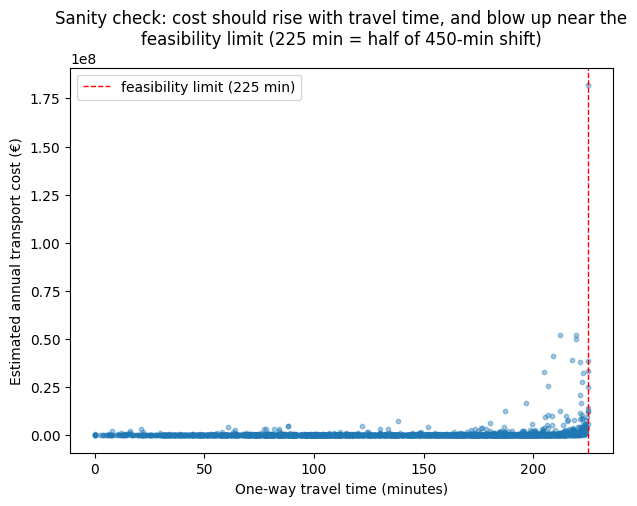

In [15]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(sanity["travelTime"], sanity["transportationCosts"], alpha=0.4, s=10)
ax.set_xlabel("One-way travel time (minutes)")
ax.set_ylabel("Estimated annual transport cost (€)")
ax.set_title("Sanity check: cost should rise with travel time, and blow up near the\nfeasibility limit (225 min = half of 450-min shift)")
ax.axvline(shift_min / 2, color="red", linestyle="--", linewidth=1, label="feasibility limit (225 min)")
ax.legend()
plt.show()

On the first look, the transportation costs look plausible. Transport cost rises with one-way travel time, and rises steeply as travel time approaches the 225-minute feasibility limit. This matches the shape of our formula, where the denominator shrinks toward zero. 

But there is one Irregularity we need to check before proceeding. We can see six (warhouse, region) pairs with a travel time of 0, but the transportation cost varies by a lot. For travel time 0, the denominator is 450 for each of those rows, so differences in costs can only come from variation in yearly demand and/or minutes per stop. Mathematically this is correct, but we still check whether the center is standing in the exact center of the region: 

In [16]:
warehouses_flat = warehouses.reset_index()

sanity[sanity["travelTime"] == 0][["warehouseID", "regionID"]].merge(
    warehouses_flat[["warehouseID", "city"]], on="warehouseID"
).merge(
    regions_flat[["regionID", "city", "zipCode"]], on="regionID"
)

,warehouseID,regionID,city_x,city_y,zipCode
0,18,326,Granada,"OGIJARES, LOS",18151
1,23,324,Jaen,JAEN,23009
2,33,48,Oviedo,GRANDA (SIERO),33199
3,37,246,Salamanca,SANTA MARTA DE TORMES,37900
4,42,51,Soria,SORIA,42005
5,45,475,Toledo,TOLEDO,45007


The check confirms this is not a data issue: in every case the warehouse city is either identical to the region's city (e.g. Jaen–JAEN, Soria–SORIA, Toledo–TOLEDO) or a directly neighbouring tow (e.g. Oviedo–Siero, Granada–Ogíjares). These are simply regions whose center is the same city as the cash center, so a travel time of zero is exactly what we would expect. We can therefore conclude that entries with large variations in transportation costs while having similar travel times, are solely driven by variance in yearlyDemand * minutesPerStop

### Validating against the benchmark file

To check our formula, we compare it against the course's reference file shifts_with_costs.csv. We restrict this comparison to the reachable links only. Those are the only ones our cost formula actually produces and the only ones that feed into the model we solve. The benchmark's unreachable-link placeholder is not something our model uses, so comparing it would not tell us anything about whether our formula is correct.

In [17]:
benchmark = shifts_ref_long.copy()

comparison = cost_base.merge(
    benchmark[["warehouseID", "regionID", "transportationCosts"]],
    on=["warehouseID", "regionID"],
    how="left",
    suffixes=("_own", "_benchmark"),
)

# Sanity check: hat jede unserer reachable rows eine Entsprechung in der Referenz?
n_missing = comparison["transportationCosts_benchmark"].isna().sum()
print(f"Reachable rows without a benchmark match: {n_missing} of {len(comparison):,}")

comparison["rel_diff"] = (
    (comparison["transportationCosts_own"] - comparison["transportationCosts_benchmark"]).abs()
    / comparison["transportationCosts_benchmark"]
)
comparison["rel_diff"].describe()

Reachable rows without a benchmark match: 0 of 2,661


count    2.661000e+03
mean     2.461919e-16
std      1.075623e-15
min      0.000000e+00
25%      0.000000e+00
50%      1.132126e-16
75%      1.699679e-16
max      1.789375e-14
Name: rel_diff, dtype: float64

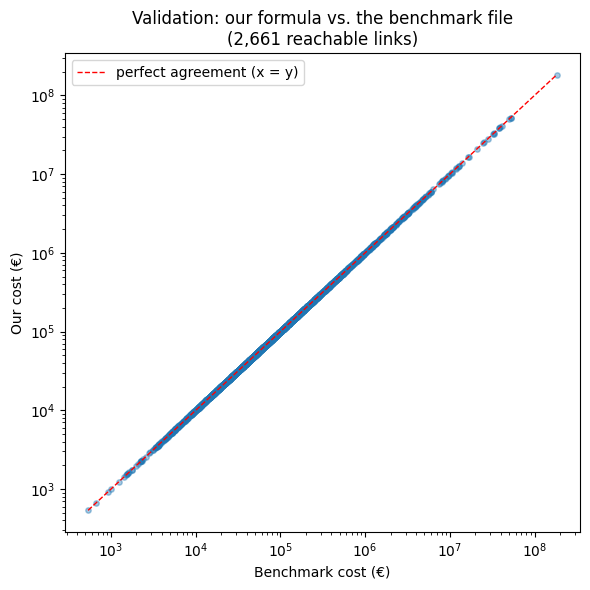

In [18]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(
    comparison["transportationCosts_benchmark"],
    comparison["transportationCosts_own"],
    alpha=0.4,
    s=15,
)

# x = y Referenzlinie: perfekte Übereinstimmung läge exakt auf dieser Geraden
lims = [comparison["transportationCosts_benchmark"].min(), comparison["transportationCosts_benchmark"].max()]
ax.plot(lims, lims, color="red", linestyle="--", linewidth=1, label="perfect agreement (x = y)")

ax.set_xlabel("Benchmark cost (€)")
ax.set_ylabel("Our cost (€)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Validation: our formula vs. the benchmark file\n(2,661 reachable links)")
ax.legend()
plt.tight_layout()
plt.show()

The relative difference between our formula and the benchmark is effectively zero for all 2,661 reachable links.

The median, the 25th percentile, and even the minimum are exactly zero. The largest observed difference (approximately $4 \times 10^{-16}$) is extremely small and can reasonably be attributed to rounding errors rather than a meaningful discrepancy. In the scatter plot below, every point falls exactly on the x = y line (shown on a log-log scale). No data point deviates visibly from perfect agreement, consistent with the near-zero relative differences
seen in the table. These results show that our derived cost formula reproduces the benchmark values exactly for all practical purposes, providing strong evidence that the derivation is correct rather than merely a close approximation.

## 4. Extending the model to fix the remaining problem

We identified three reasons why the baseline Warehouse-Location model does not fit CashLog. The first two, an undefined $c_{ij}$ and too many individual customers, are already solved. We derived and validated the cost formula and the customer clustering into 515 regions was already provided in the raw dataset. The third problem remains. The baseline model assumes each center has a
fixed capacity and a constant fixed cost, whereas at CashLog capacity is a
strategic, investable choice, and cost follows economies of scale.

We now extend the model directly to address this. Introducing discrete center-size tiers with their own capacity range and cost structure.

### The extended cost function

Our extended objective combines three cost components:

$$\min\; \underbrace{\sum_i\sum_j x_{ij}\,c_{ij}}_{\text{transport (already solved)}} \;+\; \underbrace{\sum_i f_i\,y_i}_{\text{real, individual fixed cost}} \;+\; \underbrace{\sum_i\sum_t c_t^{var}\,z_{it}}_{\text{size-dependent processing cost, new}}$$


The first term is already fully derived and validated. The second term uses each center's real fixed cost directly from the warehouses dataset. We already have this information for every individual center, so replacing it with a coarser tier average would throw away real data. The third term is new. It captures volume-dependent variable processing cost inside the center, which is not covered by the transport formula and is not constant per delivery due to economies of scale.

To make the third term concrete, we need two things we do not yet have:

1. a classification of each center into a size tier
2. a per-tier processing cost $c_t^{var}$ that falls with tier size. 

We derive both from the data below, before writing the full set of decision variables and constraints.

#### Center Size Tiers

We start with classification of the cash centers into different size-tiers. The dataset does not contain a direct measure of the center's physical capacity, so we use the fixed cost entry for every warehouse as a proxy for physical warehouse size. The fixed costs of running a warehouse is usually driven by parameters like square footage, electricity costs, salary costs and regional price level. Mostly indicators of physical size. 

The idea is to derive tier boundaries from natural gaps in the fixed-cost distribution. This remains an assumption, as fixed cost correlates with size but is not the same thing, so the resulting tiers are a reasonable approximation, not a precise capacity measurement.

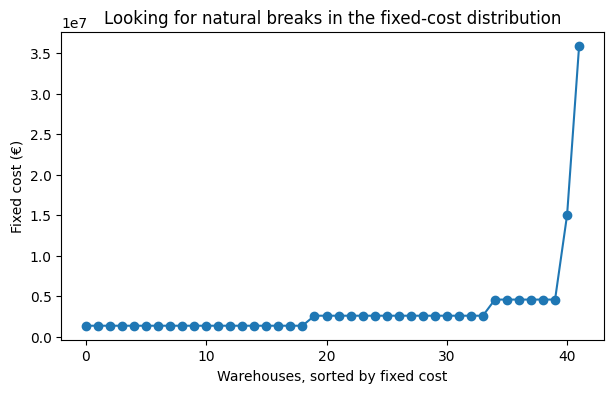

In [19]:
sorted_costs = warehouses_flat["fixedCosts"].sort_values().reset_index(drop=True)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(len(sorted_costs)), sorted_costs, marker="o")
ax.set_xlabel("Warehouses, sorted by fixed cost")
ax.set_ylabel("Fixed cost (€)")
ax.set_title("Looking for natural breaks in the fixed-cost distribution")
plt.show()

In [20]:
#biggest gaps in the fixed-cost distribution
gaps = sorted_costs.diff()
gap_summary = pd.DataFrame({
    "index": range(len(sorted_costs)),
    "fixedCosts": sorted_costs,
    "gap_to_previous": gaps,
}).sort_values("gap_to_previous", ascending=False)

gap_summary.head(6)

,index,fixedCosts,gap_to_previous
41,41,35904000,20892000.0
40,40,15012000,10440000.0
34,34,4572000,1992000.0
19,19,2580000,1236000.0
5,5,1344000,0.0
2,2,1344000,0.0


In [21]:
sorted_costs.iloc[0]        # der Wert an Position 0 = der gemeinsame Tier-1-Wert
sorted_costs.iloc[:19].nunique()   # sollte 1 sein, bestätigt "alle 19 identisch"

print(sorted_costs.iloc[0])
print(sorted_costs.iloc[:19].nunique())

1344000
1


In [22]:
#check if we considered all warehouses
n_unique = warehouses_flat["fixedCosts"].nunique()
counts = warehouses_flat["fixedCosts"].value_counts().sort_index()
print(f"Distinct values: {n_unique}")
print(counts)
print(f"Sum of counts: {counts.sum()} (should be 42)")

Distinct values: 5
fixedCosts
1344000     19
2580000     15
4572000      6
15012000     1
35904000     1
Name: count, dtype: int64
Sum of counts: 42 (should be 42)


The gap analysis reveals that all 42 warehouses fall into exactly five distinct fixed-cost levels.

| Tier | Fixed Cost (€) | Number of Warehouses |
| ---- | -------------: | -------------------: |
| 1    |      1,344,000 |                   19 |
| 2    |      2,580,000 |                   15 |
| 3    |      4,572,000 |                    6 |
| 4    |     15,012,000 |                    1 |
| 5    |     35,904,000 |                    1 |

These results provide strong, data-driven support for using five size tiers. While the two largest tiers each contain only a single warehouse, we retain them as separate categories rather than merging them. Their fixed costs (€15.0M and €35.9M) represent clearly distinct capacity levels rather than minor variation around a common value.

We map each warehouse to its size tier directly via its fixed-cost value, since there are exactly five distinct values, this mapping is exact, not an approximation or a clustering result with ambiguous boundary cases.

In [23]:
tier_by_fixed_cost = {
    1_344_000: "v",
    2_580_000: "s",
    4_572_000: "m",
    15_012_000: "l",
    35_904_000: "h",
}

warehouses_flat["tier"] = warehouses_flat["fixedCosts"].map(tier_by_fixed_cost)
warehouses_flat[["warehouseID", "city", "fixedCosts", "tier"]]

,warehouseID,city,fixedCosts,tier
0,1,Vitoria,1344000,v
1,2,Albacete,2580000,s
2,3,Alicante,4572000,m
3,4,Almeria,2580000,s
4,5,Avila,1344000,v
5,8,Barcelona,15012000,l
6,9,Burgos,1344000,v
7,10,Caceres,2580000,s
8,13,Ciudad real,1344000,v
9,14,Cordoba,2580000,s


#### Variable processing costs

Having classified each cash center into a size tier, we now derive the variable processing cost per delivery ($c_t^{var}$) for each tier. Rather than guessing five independent values, we scale a single anchor value using the fixed-cost ratios between tiers we already established above. Since fixed cost is our size proxy, a larger tier's fixed-cost ratio also tells us how much bigger it likely is, and economies of scale mean the variable cost per delivery should fall accordingly.

Note the unit: $c_t^{var}$ is cost *per individual customer visit*, not per shift or per tour, unlike $c_{ij}$, which already aggregates many visits into a single shift cost.

In [24]:
fixed_by_tier = {"v": 1_344_000, "s": 2_580_000, "m": 4_572_000, "l": 15_012_000, "h": 35_904_000}
scale_factor = {t: f / fixed_by_tier["v"] for t, f in fixed_by_tier.items()}
scale_factor

{'v': 1.0,
 's': 1.9196428571428572,
 'm': 3.4017857142857144,
 'l': 11.169642857142858,
 'h': 26.714285714285715}

The smallest warehouse tier (v) is used as the reference with a scaling factor of 1.0. The remaining scaling factors are calculated by dividing each tier's fixed cost by the fixed cost of the smallest tier, providing a relative measure across warehouse sizes.



#### Dampening the scaling effect

Having derived the fixed-cost ratios between tiers, we now decide how strongly variable cost per delivery should decrease as warehouse size increases. A one-to-one translation of the fixed-cost ratio into variable cost savings would be unrealistically strong. While fixed costs primarily reflect investments in capacity (e.g., warehouse space, equipment, and security infrastructure), operational efficiencies per delivery are subject to physical and organizational limits and therefore cannot improve proportionally with warehouse size. To account for this, we dampen the scaling effect rather than applying the fixed-cost ratios directly, thereby representing economies of scale in a more realistic manner.

We implement this using a power function. Let $s_t$ denote the fixed-cost scaling factor of tier $t$ relative to the smallest warehouse tier. The variable processing cost per delivery is then calculated as

$$c_t^{var} = c_v^{var} \cdot s_t^{-\alpha}$$

where $c_v^{var}$ is the variable processing cost per delivery of the reference tier and $\alpha$ is the dampening exponent. The parameter $\alpha$ controls the strength of the economies of scale: $\alpha=0$ implies no scaling effect at all, $\alpha=1$ would apply the fixed-cost ratio directly, and intermediate values produce a moderate, more plausible reduction. Since $\alpha$ is the only free parameter of the function and has a clear interpretation, it can be systematically varied in the sensitivity analysis to assess the robustness of the model.

We set $\alpha = 0.5$ (square-root dampening) as our base case. It represents a moderate, commonly used degree of scale sensitivity. Strong enough to reflect real economies of scale, but far short of a full 1:1 translation of the fixed-cost ratio. We treat $\alpha$ as an explicit assumption and vary it later in the sensitivity analysis.

##### Deriving $c_v^{var}$

The scaled variable processing costs depend on the initital reference $c_v^{var}$. It therefore needs to be a sensible and defensible value. We initialize $c_v^{var}$ using our own transport cost as an internal reference point:

for each reachable link, we can compute the transport cost per individual delivery($c_{ij}/\text{yearlyDemand}_j$).

In-house processing (counting, sorting) requires no vehicle or fuel, and plausibly less staff time per delivery than a driven tour stop, so we expect it to cost less than transport per delivery. We therefore set $c_v^{var}$ at a sensible fraction of the median transport-per-delivery figure. The percentage itself remains an assumption (we have no data separating processing from transport labor), but the anchor point it scales from is fully derived from our own data, not an external or invented number. We will later consider the impact of that assumption in our sensitivity analysis

In [25]:
#dampened scaling factors berechnen
damp_scale_factor = {t: f ** (-0.5) for t, f in scale_factor.items()}
damp_scale_factor

{'v': 1.0,
 's': 0.7217549671170539,
 'm': 0.5421837830414847,
 'l': 0.29921292969750063,
 'h': 0.19347649748797371}

In [26]:
#per delivery transport cost = yearly total transport cost per link / yearly demand of the region
#cost_base = df mit den transportkosten pro link
merged = cost_base.merge(regions_flat[["regionID", "yearlyDemand"]], on="regionID")
merged["per_delivery_transport_cost"] = merged["transportationCosts"] / merged["yearlyDemand"]

merged["per_delivery_transport_cost"].describe()

count     2661.000000
mean       265.015739
std       2312.927160
min          7.425495
25%         27.939908
50%         47.116959
75%        106.498884
max      66212.112924
Name: per_delivery_transport_cost, dtype: float64

The median transport cost per delivery across all 2,661 reachable links is 47.12€. We estimate in-house processing costs at roughly **15%** of this transport-per-delivery figure, reasoning that the bulk of a transport stop's cost is driving and logistics overhead rather than the few minutes of actual cash handling. This gives:

$$c_v^{var} = 0.15 \times 47.12€ \approx 7.07€ \text{ per delivery}$$

We can now calculate the scaled processing costs 

In [27]:
alpha = 0.5       # dampening exponent

median_transport_per_delivery = merged["per_delivery_transport_cost"].median()
processing_share = 0.15  # Anteil der Transport-pro-Lieferung-Kosten

c_var_anchor = processing_share * median_transport_per_delivery
print(f"c_v^var anchor: {c_var_anchor:.2f} € per delivery")

c_var_by_tier = {t: c_var_anchor / (scale_factor[t] ** alpha) for t in scale_factor}
c_var_by_tier

c_v^var anchor: 7.07 € per delivery


{'v': np.float64(7.06754383931803),
 's': np.float64(5.101034871345321),
 'm': np.float64(3.8319076556129894),
 'l': np.float64(2.1147004979278696),
 'h': np.float64(1.367403627873959)}

The resulting variable processing costs range from 7.07€ per delivery for the smallest tier down to 1.37€ for the largest. A 5.2x reduction, matching $\sqrt{s_h} \approx 5.17$ as expected from $\alpha=0.5$. This is substantially smaller than the 26.7x difference in fixed costs between the same two tiers, confirming that our dampening meaningfully moderates the raw fixed-cost ratio rather than passing it through unchanged. All values remain well below the median transport cost per delivery (47.12€), consistent with in-house processing being cheaper per unit than a driven tour stop.

We now have every parameter needed to build our extended model

## The complete extended model, as we implement it

**Sets and indices**
- $i$ — cash center (warehouse), $i\in\{1,\dots,42\}$
- $j$ — customer region, $j\in\{1,\dots,515\}$
- Only pairs $(i,j)$ that are reachable within a single shift are considered
  (2,661 of the 21,630 possible pairs), all others are simply
  not included as variables.

**Parameters (all derived above)**
| Symbol | Meaning | Source |
|---|---|---|
| $c_{ij}$ | annual transport cost, center $i$ to region $j$ | derived & validated in previous part |
| $d_j$ | annual demand (deliveries) of region $j$ | regions["yearlyDemand"] |
| $f_i$ | annual fixed cost of center $i$ | warehouses["fixedCosts"] (real, individual) |
| $\text{tier}(i)$ | size tier of center $i$ (v/s/m/l/h) | derived from $f_i$ (exactly 5 distinct values) |
| $c_{\text{tier}(i)}^{var}$ | processing cost per delivery for center $i$'s tier | derived from fixed-cost scaling + damping ($\alpha=0.5$) + transport-cost anchor |

**Decision variables**
- $x_{ij}\in\{0,1\}$ — region $j$ is served by center $i$
- $y_i\in\{0,1\}$ — center $i$ is open

**Objective**

$$\min \sum_{(i,j)\text{ reachable}} x_{ij}\Big(c_{ij} + c_{\text{tier}(i)}^{var}\cdot d_j\Big) \;+\; \sum_i f_i\,y_i$$

**Constraints**

$$x_{ij} \le y_i \qquad \forall (i,j)\text{ reachable}$$
$$\sum_{i:(i,j)\text{ reachable}} x_{ij} = 1 \qquad \forall j$$
$$x_{ij}, y_i \in \{0,1\}$$

Since the annual demand assigned to warehouse $(i)$ is given by

$$z_i=\sum_{j:(i,j)\text{ reachable}} d_j\, x_{ij}$$

it is already a linear expression in the assignment variables. Substituting this expression directly into the objective yields an equivalent formulation in which the variable processing cost is incorporated into the effective assignment cost

$$c_{ij}+c_{\text{tier}(i)}^{var}d_j$$

This avoids introducing an additional decision variable while preserving the linearity of the optimization model.

In [28]:
# step 1: calculating effective costs

model_data = (
    cost_base
    .merge(regions_flat[["regionID", "yearlyDemand"]], on="regionID")
    .merge(warehouses_flat[["warehouseID", "tier", "fixedCosts"]], on="warehouseID")
)
model_data["c_var_i"] = model_data["tier"].map(c_var_by_tier)
model_data["effective_cost"] = (
    model_data["transportationCosts"] + model_data["c_var_i"] * model_data["yearlyDemand"]
)

model_data[["warehouseID", "regionID", "transportationCosts", "c_var_i", "effective_cost"]].head()

,warehouseID,regionID,transportationCosts,c_var_i,effective_cost
0,1,481,11984.212729,7.067544,14747.622370
1,1,484,1768.151568,7.067544,2171.001567
2,1,506,26401.950120,7.067544,32077.187823
3,1,201,532284.472371,7.067544,700188.111361
4,1,50,102714.862299,7.067544,110750.659644


In [29]:
# step 2: pulp problem setup

prob = pl.LpProblem("CashLog_Extended", pl.LpMinimize)

# x_ij nur für die 2.661 tatsächlich erreichbaren Paare, kein Big-M nötig 
link_keys = list(zip(model_data["warehouseID"], model_data["regionID"]))
x = pl.LpVariable.dicts("x", link_keys, cat="Binary")

# y_i für alle 42 Center
all_warehouse_ids = warehouses_flat["warehouseID"].tolist()
y = pl.LpVariable.dicts("y", all_warehouse_ids, cat="Binary")

#objective function

transport_and_processing_cost = pl.lpSum(
    row.effective_cost * x[(row.warehouseID, row.regionID)]
    for row in model_data.itertuples()
)
fixed_cost = pl.lpSum(
    f * y[i] for i, f in zip(warehouses_flat["warehouseID"], warehouses_flat["fixedCosts"])
)

prob += transport_and_processing_cost + fixed_cost

#constraints

# Region kann nur einem offenen Center zugeordnet werden
for i, j in link_keys:
    prob += x[(i, j)] <= y[i]

# jede Region wird genau einem (erreichbaren) Center zugeordnet
for j in regions_flat["regionID"]:
    reachable_i = [i for (i, jj) in link_keys if jj == j]
    prob += pl.lpSum(x[(i, j)] for i in reachable_i) == 1

#solve the problem

status = prob.solve(pl.PULP_CBC_CMD(msg=1))
print("Status:", pl.LpStatus[status])
print("Total cost: €", round(pl.value(prob.objective), 2))

Status: Optimal
Total cost: € 117082899.44


In [30]:
open_centers = [i for i in all_warehouse_ids if y[i].value() == 1]
n_open = len(open_centers)
print(f"Open centers: {n_open} of 42")
print(f"Closed centers: {42 - n_open}")

assigned_tiers = warehouses_flat.set_index("warehouseID").loc[open_centers, ["city", "fixedCosts", "tier"]]
print(f"Overview of the {assigned_tiers["city"].count()} open centers:")
assignment = [(i, j) for (i, j) in link_keys if x[(i, j)].value() == 1]
print(f"Total assignments: {len(assignment)}")

num_tiers = assigned_tiers["tier"].value_counts().sort_index()

display(assigned_tiers.sort_values("fixedCosts"))
print(num_tiers)

Open centers: 18 of 42
Closed centers: 24
Overview of the 18 open centers:
Total assignments: 515


,city,fixedCosts,tier
warehouseID,,,
1,Vitoria,1344000,v
5,Avila,1344000,v
16,Cuenca,1344000,v
9,Burgos,1344000,v
22,Huesca,1344000,v
21,Huelva,1344000,v
19,Guadalajara,1344000,v
17,Gerona,1344000,v
23,Jaen,1344000,v


tier
m     1
s     4
v    13
Name: count, dtype: int64


In [31]:
# Karte 1: Offene/geschlossene Lager
center_lat = warehouses_flat["lat"].mean()
center_lon = warehouses_flat["lon"].mean()

m1 = folium.Map(location=[center_lat, center_lon], zoom_start=6,
                tiles="cartodbpositron")

for row in warehouses_flat.itertuples():
    is_open = row.warehouseID in open_centers

    folium.CircleMarker(
        location=[row.lat, row.lon],
        radius=9 if is_open else 5,
        color="#2ca02c" if is_open else "#d62728",
        fill=True,
        fill_opacity=0.85,
        popup=f"{row.city} (ID {row.warehouseID})"
    ).add_to(m1)

# Karte 2: Regionen-Zuordnung
# Zuordnung als DataFrame: welche Region gehört zu welchem offenen Center
assignment_df = pd.DataFrame(assignment, columns=["warehouseID", "regionID"])
assignment_df = assignment_df.merge(regions_flat[["regionID", "lat", "lon", "city"]], on="regionID")

m2 = folium.Map(location=[center_lat, center_lon], zoom_start=6,
                tiles="cartodbpositron")

cmap = plt.cm.get_cmap("tab20", len(open_centers))

color_by_center = {
    wid: mcolors.to_hex(cmap(i))
    for i, wid in enumerate(open_centers)
}

# Lagerstandorte
color_by_center = {
    wid: mcolors.to_hex(cmap(i))
    for i, wid in enumerate(open_centers)
}

for row in assignment_df.itertuples():

    folium.CircleMarker(
        location=[row.lat, row.lon],
        radius=2,
        color=color_by_center.get(row.warehouseID, "#999999"),
        fill=True,
        fill_opacity=0.6,
    ).add_to(m2)

# Regionen
for row in warehouses_flat.itertuples():

    is_open = row.warehouseID in open_centers

    folium.CircleMarker(
        location=[row.lat, row.lon],
        radius=8 if is_open else 5,
        color=color_by_center.get(row.warehouseID, "#999999"),
        fill=True,
        fill_color=color_by_center.get(row.warehouseID, "#999999"),
        fill_opacity=1,
    ).add_to(m2)

display(m1)
display(m2)

C:\Users\t.ludwig\AppData\Local\Temp\ipykernel_37540\2874516833.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(open_centers))


In [32]:
madrid_region_id = regions_flat.loc[regions_flat["city"].str.contains("MADRID", case=False), "regionID"]
assignment_df[assignment_df["regionID"].isin(madrid_region_id)]

barcelona_region_id = regions_flat.loc[regions_flat["city"].str.contains("BARCELONA", case=False), "regionID"]
assignment_df[assignment_df["regionID"].isin(barcelona_region_id)]

display(assignment_df[assignment_df["regionID"].isin(madrid_region_id)])
display(assignment_df[assignment_df["regionID"].isin(barcelona_region_id)])

,warehouseID,regionID,lat,lon,city
282,19,90,40.3921,-3.7728,MADRID
284,19,244,40.4975,-3.6637,MADRID


,warehouseID,regionID,lat,lon,city
487,43,438,41.378,2.1278,BARCELONA


The optimal network keeps 18 of 42 centers open, serving all 515 regions. The open set is dominated by small ("v") tiers (13 of 18), with a handful of "s" and one "m" center, but no "l" or "h" centers. This suggests that, under our cost assumptions, the fixed-cost savings of many small centers outweigh the processing-cost efficiencies a few very large centers would offer. 
No single region's demand concentration is large enough to justify the 15M€+/35M€+ fixed cost, even at their lower per-delivery processing cost.

The map confirms this is not just a numerical artifact but a geographically sensible outcome. The two most expensive centers (Madrid and Barcelona), are both closed, yet the surrounding demand remains fully covered. Nearby, much cheaper "s" or "v"-tier centers pick up the regions that would otherwise have been served from the metropolis itself.

This is a direct illustration of the network effects we warn about at the beginning. A center's value cannot be judged by whether it is a good location in isolation, but by whether a cheaper combination of other open centers can serve the same demand just as well. Here, the model finds exactly such a combination: Madrid's demand (regions 90 and 244) is served by Warehouse 19 (Guadalajara, tier "v", 1.34M€ fixed cost), and Barcelona's demand (region 438) is served by Warehouse 43 (Tarragona, tier "s", 2.58M€ fixed cost).

Madrid and Barcelona are not "bad locations" in themselves. Opposingly, they sit at the center of Spain's highest-demand areas, but the network as a whole is cheaper without them, because their demand can be absorbed by nearby centers at a fraction of what a facility directly in either metropolis would have cost.

This conclusion depends on our economies-of-scale assumption ($\alpha=0.5$). A stronger scaling effect could make large centers more attractive. We test this explicitly in the sensitivity analysis below.

#### Checking our no-volume-cap decision

Before continuing with the Sensitivity Analysis, we have to account for one more potential problem.
We earlier chose not to impose explicit volume caps per tier, since we had
no real capacity data to set them credibly. We now verify this
was safe

In [33]:
volume_per_center = (
    assignment_df.merge(regions_flat[["regionID", "yearlyDemand"]], on="regionID")
    .groupby("warehouseID")["yearlyDemand"]
    .sum()
    .rename("assigned_volume")
)

volume_check = (
    warehouses_flat.set_index("warehouseID")
    .loc[open_centers, ["city", "tier", "fixedCosts"]]
    .join(volume_per_center)
    .sort_values("tier")
)
display(volume_check)

tier_volume_stats = volume_check.groupby("tier")["assigned_volume"].describe()
display(tier_volume_stats)

guadalajara_regions = assignment_df[assignment_df["warehouseID"] == 19]
display(guadalajara_regions.merge(shifts_long, on=["warehouseID", "regionID"])[["regionID", "travelTime"]].describe())

,city,tier,fixedCosts,assigned_volume
warehouseID,,,,
3,Alicante,m,4572000,245965
4,Almeria,s,2580000,36836
10,Caceres,s,2580000,54712
14,Cordoba,s,2580000,74841
43,Tarragona,s,2580000,357127
1,Vitoria,v,1344000,293753
32,Orense,v,1344000,91506
27,Lugo,v,1344000,85357
24,Leon,v,1344000,93638


,count,mean,std,min,25%,50%,75%,max
tier,,,,,,,,
m,1.0,245965.000000,NaN,245965.0,245965.0,245965.0,245965.0,245965.0
s,4.0,130879.000000,151628.837062,36836.0,50243.0,64776.5,145412.5,357127.0
v,13.0,160608.692308,179401.484513,39283.0,85357.0,91506.0,152305.0,716917.0


,regionID,travelTime
count,29.000000,29.000000
mean,302.310345,84.411584
std,143.420238,37.572934
min,83.000000,6.593524
25%,165.000000,61.000000
50%,330.000000,83.000000
75%,434.000000,108.000000
max,513.000000,183.209671


Warehouse 19 (Guadalajara, tier "v", 1.34M€ fixed cost) is assigned 716,917 units of demand, across 19 regions. Nearly 8x the median volume among "v"-tier centers (91,506) and more than every "s"-tier center and the single "m"-tier center. This is the same location that absorbs Madrid's demand.

Its travel times to these regions range from 6.6 to 183.2
minutes (median 83), comfortably below our 225-minute feasibility limit. 
So this is not an artifact of barely-reachable links being forced together.
Guadalajara is simply very centrally located
and can therefore reach many regions efficiently. The geographic logic is
sound. The open question is a different one. Whether a facility built at
the fixed-cost level of our smallest tier could physically handle this
volume in reality.


This is a direct consequence of not capping volume, and we accept it as a disclosed limitation rather than an error. Without real capacity data, any cap we could impose would itself be an unfounded number. The alternative, trusting an invented cap, would not be more defensible than trusting the model's cost logic here. We flag Guadalajara's assignment as a point CashLog should verify against Guadalajara's actual physical capacity and test the sensitivity of our results to this assumption directly below by re-solving the model with volume caps derived
from the observed distribution.

### Comparison

As a comparison scenario, we cap each tier's volume at 1.5x its own 75th
percentile from the uncapped solution. Not because this is a known real
capacity, but to test how much the recommendation changes if no center is
allowed to carry a disproportionate share of demand relative to its peers
of the same tier.

We compute this percentile excluding Guadalajara itself. Including the
very outlier we want to constrain would let it inflate the percentile meant
to limit it, weakening the cap exactly where it matters most.

Using the raw 75th percentile as a hard cap would still penalize any center
simply on the higher end of normal variation within its tier, not just
genuine outliers. The 1.5x multiplier is itself a judgment call, chosen to
give reasonable headroom for normal variation while still meaningfully
constraining extreme cases like Guadalajara (716,917 — still nearly 3.7x
even this corrected "v"-tier cap).

In [34]:
GUADALAJARA_ID = 19

volume_excl_outlier = volume_check.drop(index=GUADALAJARA_ID)  # falls warehouseID der Index ist
tier_volume_stats_clean = volume_excl_outlier.groupby("tier")["assigned_volume"].describe()

V_ub_by_tier = (tier_volume_stats_clean["75%"] * 1.5).to_dict()
# Für Tiers ohne beobachtetes Volumen in der Basislösung (l, h) setzen wir keine cap, da keine Referenzverteilung existiert, aus der sich ein plausibler Cap ableiten ließe.
for missing_tier in ["l", "h"]:
    if missing_tier not in V_ub_by_tier:
        V_ub_by_tier[missing_tier] = float("inf")

V_ub_by_tier

{'m': 368947.5, 's': 218118.75, 'v': 191234.625, 'l': inf, 'h': inf}

Note: the "m" tier's cap is based on a single observed center (Alicante), so its 75th percentile is simply that center's own volume. Less robust than the "v"/"s" caps, which are based on more centers respectively. We proceed with it as a reasonable approximation, since Alicante's own assigned volume is well within this self-referential cap by construction.

In [35]:
warehouse_tier = warehouses_flat.set_index("warehouseID")["tier"]

prob_capped = pl.LpProblem("CashLog_Extended_Capped", pl.LpMinimize)
x_c = pl.LpVariable.dicts("x", link_keys, cat="Binary")
y_c = pl.LpVariable.dicts("y", all_warehouse_ids, cat="Binary")

prob_capped += pl.lpSum(
    row.effective_cost * x_c[(row.warehouseID, row.regionID)] for row in model_data.itertuples()
) + pl.lpSum(f * y_c[i] for i, f in zip(warehouses_flat["warehouseID"], warehouses_flat["fixedCosts"]))

for i, j in link_keys:
    prob_capped += x_c[(i, j)] <= y_c[i]
for j in regions_flat["regionID"]:
    reachable_i = [i for (i, jj) in link_keys if jj == j]
    prob_capped += pl.lpSum(x_c[(i, j)] for i in reachable_i) == 1

demand_by_link = model_data.set_index(["warehouseID", "regionID"])["yearlyDemand"]
for i in all_warehouse_ids:
    cap = V_ub_by_tier[warehouse_tier[i]]
    if cap == float("inf"):
        continue  # l/h bleiben ungekappt, siehe Begründung oben
    links_for_i = [(ii, j) for (ii, j) in link_keys if ii == i]
    prob_capped += pl.lpSum(
        demand_by_link[(i, j)] * x_c[(i, j)] for (ii, j) in links_for_i
    ) <= cap * y_c[i]

status_c = prob_capped.solve(pl.PULP_CBC_CMD(msg=0))
print("Status:", pl.LpStatus[status_c])
print("Total cost: €", round(pl.value(prob_capped.objective), 2))

Status: Optimal
Total cost: € 146803705.49


In [36]:
open_centers_capped = [i for i in all_warehouse_ids if y_c[i].value() == 1]
print(f"Open centers: {len(open_centers_capped)} of 42")
display(warehouses_flat.set_index("warehouseID").loc[open_centers_capped, ["city", "tier", "fixedCosts"]].sort_values("tier"))
display(warehouses_flat.set_index("warehouseID").loc[open_centers_capped, "tier"].value_counts())

if 19 in open_centers_capped:
    print("Guadalajara still open")
else:
    print("Guadalajara closed in the capped scenario")

Open centers: 19 of 42


,city,tier,fixedCosts
warehouseID,,,
28,Madrid,h,35904000
3,Alicante,m,4572000
4,Almeria,s,2580000
10,Caceres,s,2580000
14,Cordoba,s,2580000
43,Tarragona,s,2580000
39,Santander,s,2580000
25,Lerida,s,2580000
1,Vitoria,v,1344000


tier
v    11
s     6
m     1
h     1
Name: count, dtype: int64

Guadalajara closed in the capped scenario


The capped comparison confirms that Guadalajara's role in the base solution
was not incidental. When no center may exceed the 1.5x-buffered, outlier-
excluded volume typical for its tier, the network changes in a very
specific way, Guadalajara (previously absorbing 716,917 units, including
Madrid's demand) closes, and Madrid itself reopens. This time as an "h"-
tier facility. The model effectively substitutes one
large, expensive hub for another, rather than spreading Madrid's demand
thinly across several small centers. This tells us Madrid's surrounding
demand is large enough to require either (a) a genuinely large facility, or
(b) an artificially overloaded small one. A "normal-sized" small center
cannot absorb it.

The network also shifts from mostly "v"-tier (13 of 18) to a more balanced
mix (11 "v", 6 "s", one "m", one "h"), with one more center open overall
(19 vs. 18). Total cost rises by 25.4% (+€29.7M). A substantial amount,
confirming that a meaningful share of the base solution's efficiency came
specifically from allowing Guadalajara to operate far outside its tier's
typical volume range.

| Metric | Uncapped (base) | Capped |
|---|---:|---:|
| Total annual cost | €117,082,899 | €146,803,705 |
| Cost difference | — | +€29,720,806 (+25.4%) |
| Open centers | 18 | 19 |
| Tier mix (v / s / m / l / h) | 13 / 4 / 1 / 0 / 0 | 11 / 6 / 1 / 0 / 1 |
| Guadalajara (WH 19) | open  | closed |
| Madrid (WH 28) | closed | open (h-tier) |

**What this means for our recommendation:** the base (uncapped) solution is
the cost-optimal answer given our assumptions, but it relies on one
specific center (Guadalajara) handling a volume that may not be physically
realistic for a facility built at its fixed-cost level. If CashLog can
confirm Guadalajara has (or can be upgraded to have) this capacity, the base
recommendation stands. If not, the capped alternative, closing Guadalajara
and reopening Madrid directly, is the more defensible choice,
at a cost of roughly 25% higher annual expenditure.

Having validated the base model and quantified its main limitation, 
Guadalajara's uncapped volume, and the 25.4% cost of the more conservative
capped alternative, we now shift focus from internal consistency to
external sensitivity. Instead of asking whether the model behaves
coherently, we ask how strongly the recommended network changes when
conditions outside the model change: falling cash demand, rising wages and
fuel costs, new technology, and the strength of the economies-of-scale
effect we assumed. This is the sensitivity analysis.

## Part 5 — Sensitivity analysis (in marimo mit slider evtl.)

We test the robustness of our recommendation along four axes:

1. **Economies-of-scale strength ($\alpha$)** — our own modeling assumption;
   we check whether the dominance of small centers survives a stronger or
   weaker scaling effect.
2. **Falling cash demand** — cash usage is declining industry-wide; we test
   -10%, -30%, -50% scenarios.
3. **Rising wages and fuel costs** — we test on increasing shift cost.
4. **New technology** (autonomous vehicles) — we test reduced crew cost,
   longer usable shifts, and faster travel.

For each scenario, we re-solve the extended model and record: total cost,
number of open centers, and which centers change status relative to the
base solution. At the end, we synthesize a **robust recommendation**:
centers that stay open across all scenarios ("keep"), centers that never
reopen ("close"), and centers whose status depends on the scenario
("uncertain" — flagged for closer attention).

### 5.1 a Economies-of-scale strength ($\alpha$)

To run each scenario without duplicating the model code, we wrap the steps
from Part 4: computing $c_t^{var}$, building the effective link costs, and
solving the model into a single reusable function. This lets us vary one
parameter at a time and directly compare outcomes.

In [37]:
def solve_network(alpha=alpha, demand_factor=1.0, shift_cost=shift_cost_base,
                   shift_min=shift_min, travel_factor=1.0, processing_share=processing_share, force_open=None, force_closed=None):
    # 1. variable costs per tier unter den neuen Annahmen
    c_var_anchor_local = processing_share * median_transport_per_delivery   
    c_var = {t: c_var_anchor_local / (scale_factor[t] ** alpha) for t in scale_factor}
    
    # 2. effektive Kosten neu berechnen (Nachfrage-/Schicht-/Fahrzeit-Faktoren einbezogen)
    usable = shift_min - 2 * shifts_long["travelTime"] * travel_factor
    feasible = usable > 0
    dem = shifts_long["regionID"].map(demand_by_region) * demand_factor
    mps = shifts_long["regionID"].map(stop_time_by_region)
    cost = shift_cost * dem * mps / usable

    md = shifts_long[feasible].copy()
    md["transportationCosts"] = cost[feasible]
    md = md.merge(regions_flat[["regionID", "yearlyDemand"]], on="regionID")
    md = md.merge(warehouses_flat[["warehouseID", "tier", "fixedCosts"]], on="warehouseID")
    md["yearlyDemand"] = md["yearlyDemand"] * demand_factor
    md["c_var_i"] = md["tier"].map(c_var)
    md["effective_cost"] = md["transportationCosts"] + md["c_var_i"] * md["yearlyDemand"]

    # 3. PuLP-Modell
    keys = list(zip(md["warehouseID"], md["regionID"]))
    xs = pl.LpVariable.dicts("x", keys, cat="Binary")
    ys = pl.LpVariable.dicts("y", all_warehouse_ids, cat="Binary")

    prob = pl.LpProblem("scenario", pl.LpMinimize)
    prob += pl.lpSum(row.effective_cost * xs[(row.warehouseID, row.regionID)] for row in md.itertuples()) \
          + pl.lpSum(f * ys[i] for i, f in zip(warehouses_flat["warehouseID"], warehouses_flat["fixedCosts"]))
    for i, j in keys:
        prob += xs[(i, j)] <= ys[i]
    for j in regions_flat["regionID"]:
        reach = [i for (i, jj) in keys if jj == j]
        prob += pl.lpSum(xs[(i, j)] for i in reach) == 1
    #force_open/force_closed constraints
    for i in (force_open or []):
        prob += ys[i] == 1
    for i in (force_closed or []):
        prob += ys[i] == 0

    prob.solve(pl.PULP_CBC_CMD(msg=0))
    open_ids = [i for i in all_warehouse_ids if ys[i].value() == 1]
    assignment = [(i, j) for (i, j) in keys if xs[(i, j)].value() == 1]
    return {
        "status": pl.LpStatus[prob.status],
        "total_cost": pl.value(prob.objective),
        "open_centers": open_ids,
        "n_open": len(open_ids),
        "assignment": assignment,
    }

alpha_results = {a: solve_network(alpha=a) for a in [0.3, 0.5, 0.7, 1.0]}
pd.DataFrame({a: {"cost": r["total_cost"], "n_open": r["n_open"]} for a, r in alpha_results.items()}).T

,cost,n_open
0.3,1.177164e+08,18.0
0.5,1.170829e+08,18.0
0.7,1.164428e+08,17.0
1.0,1.150323e+08,17.0


In [38]:
# Welche Center gehen bei alpha=0.5 vs alpha=1.0 verloren?
closed_at_high_alpha = set(alpha_results[0.5]["open_centers"]) - set(alpha_results[1.0]["open_centers"])
print("Centers open at α=0.5 but closed at α=1.0:", closed_at_high_alpha)
display(warehouses_flat.loc[
    warehouses_flat["warehouseID"].isin(closed_at_high_alpha), 
    ["warehouseID", "city", "tier", "fixedCosts"]])

opened_at_high_alpha = set(alpha_results[1.0]["open_centers"]) - set(alpha_results[0.5]["open_centers"])
print("Centers open at α=1.0 but not at α=0.5:", opened_at_high_alpha)

warehouses_flat.loc[
    warehouses_flat["warehouseID"].isin(opened_at_high_alpha),
    ["warehouseID", "city", "tier", "fixedCosts"]
]

Centers open at α=0.5 but closed at α=1.0: {32, 5, 14, 19, 21}


,warehouseID,city,tier,fixedCosts
4,5,Avila,v,1344000
9,14,Cordoba,s,2580000
14,19,Guadalajara,v,1344000
16,21,Huelva,v,1344000
25,32,Orense,v,1344000


Centers open at α=1.0 but not at α=0.5: {41, 36, 45, 49}


,warehouseID,city,tier,fixedCosts
28,36,Pontevedra,s,2580000
32,41,Sevilla,m,4572000
36,45,Toledo,s,2580000
40,49,Zamora,v,1344000


At α = 1.0, five small ("v"/"s") cash centers close: Avila, Cordoba, Guadalajara, Huelva, and Orense. At the same time, four larger centers open: Pontevedra, Sevilla, Toledo, and Zamora. From a geographical perspective, this pattern appears intuitive. Based on their locations, Sevilla is likely to absorb demand previously served by Huelva and Cordoba, Toledo may take over the service areas of Avila and Guadalajara, and Pontevedra appears to replace Orense. These observations are based solely on the geographical locations of the affected cash centers. We will look at the exact reassignment of regions in the following section.


#### Closer look: verifying the reassignment

In [39]:
base_assignment = pd.DataFrame(alpha_results[0.5]["assignment"], columns=["warehouseID", "regionID"])
a1_assignment = pd.DataFrame(alpha_results[1.0]["assignment"], columns=["warehouseID", "regionID"])

# Zusammenführen: für jede Region, wer bediente sie bei α=0.5, wer bei α=1.0
merged = base_assignment.merge(a1_assignment, on="regionID", suffixes=("_base", "_a1"))

# Nur die Regionen, deren Center sich geändert hat
changed = merged[merged["warehouseID_base"] != merged["warehouseID_a1"]]

# Übersicht: von welchem Center zu welchem Center wie viele Regionen gewandert sind
reassignment_summary = (
    changed.groupby(["warehouseID_base", "warehouseID_a1"])
    .size()
    .rename("n_regions")
    .reset_index()
)

# Stadtnamen statt IDs, für Lesbarkeit
city_lookup = warehouses_flat.set_index("warehouseID")["city"]
reassignment_summary["from_city"] = reassignment_summary["warehouseID_base"].map(city_lookup)
reassignment_summary["to_city"] = reassignment_summary["warehouseID_a1"].map(city_lookup)

display(reassignment_summary[["from_city", "to_city", "n_regions"]].sort_values("n_regions", ascending=False))
print(f"Total regions with changed assignment: {len(changed)}")
print(f"Sum of reassignment_summary: {reassignment_summary['n_regions'].sum()}")


,from_city,to_city,n_regions
13,Guadalajara,Toledo,26
19,Orense,Pontevedra,25
2,Avila,Toledo,24
3,Avila,Zamora,19
14,Huelva,Sevilla,19
8,Cordoba,Sevilla,16
16,Leon,Zamora,13
7,Cordoba,Jaen,12
17,Lugo,Pontevedra,5
18,Orense,Lugo,5


Total regions with changed assignment: 189
Sum of reassignment_summary: 189


In [40]:
# Wie viele Regionen gehörten den 5 geschlossenen Centern in der Basislösung?
closed_ids = {5, 14, 19, 21, 32}
regions_from_closed = base_assignment[base_assignment["warehouseID"].isin(closed_ids)]
print(f"Regions that belonged to the 5 closed centers: {len(regions_from_closed)}")

# Wie viele der "changed"-Regionen kamen nicht von einem der 5 geschlossenen Center?
changed_not_from_closed = changed[~changed["warehouseID_base"].isin(closed_ids)]
print(f"Changed regions NOT from a closed center: {len(changed_not_from_closed)}")

Regions that belonged to the 5 closed centers: 158
Changed regions NOT from a closed center: 31


Tracing the actual region-level reassignment confirms the geographic intuition, though the picture is a bit more nuanced. In total, 189 of 515 regions are reassigned to a different center at α=1.0. Most of this comes directly from the five closing centers: Sevilla cleanly absorbs all 35 regions previously split between Huelva (19) and Cordoba (16), exactly as hypothesized. The remaining 31 regions shift between centers that stay open in both scenarios, reflecting that a change in $\alpha$ shifts relative costs across the entire network, not just locally around the centers that open or close. A detail the geographic intuition alone could not have predicted.

Despite this additional reshuffling, the broader pattern holds: stronger economies of scale reward moderate consolidation into the next tier up, not extreme centralization, unlike the capped-volume scenario tested above, where a full "h"-tier center (Madrid) had to return.

### 5.1b Processing-cost anchor sensitivity

Besides $\alpha$, our other free parameter in deriving $c_t^{var}$ was the 15% share of median transport-cost-per-delivery used to anchor $c_v^{var}$. We test whether this specific percentage matters by re-solving the model with 10% and 25% instead of 15%, holding $\alpha=0.5$ fixed.

A higher anchor share raises $c_v^{var}$ for every tier proportionally, making
in-house processing relatively more expensive across the board. This should shift the network toward favoring transport cost efficiency over processing efficiency, but since all tiers move together, we expect a much smaller effect than $\alpha$, which changes tiers relative to each
other, not just their absolute level.

In [41]:
anchor_results = {
    share: solve_network(processing_share=share) for share in [0.10, 0.15, 0.25]
}

anchor_df = pd.DataFrame({
    share: {"cost": r["total_cost"], "n_open": r["n_open"]}
    for share, r in anchor_results.items()
}).T
    
display(anchor_df)

for share in [0.10, 0.15, 0.25]:
    tiers = warehouses_flat.set_index("warehouseID").loc[anchor_results[share]["open_centers"], "tier"].value_counts()
    print(f"processing_share={share}: n_open={anchor_results[share]['n_open']}, tiers={tiers.to_dict()}")

,cost,n_open
0.10,1.109598e+08,18.0
0.15,1.170829e+08,18.0
0.25,1.284893e+08,17.0


processing_share=0.1: n_open=18, tiers={'v': 13, 's': 4, 'm': 1}
processing_share=0.15: n_open=18, tiers={'v': 13, 's': 4, 'm': 1}
processing_share=0.25: n_open=17, tiers={'v': 10, 's': 5, 'm': 2}


In [42]:
closed_anchor = set(anchor_results[0.15]["open_centers"]) - set(anchor_results[0.25]["open_centers"])
print(f"Closed at anchor_factor={0.25}:", warehouses_flat.set_index("warehouseID").loc[list(closed_anchor), "city"].tolist())

opened_anchor = set(anchor_results[0.25]["open_centers"]) - set(anchor_results[0.15]["open_centers"])
print(f"Opened at anchor_factor={0.25}:", warehouses_flat.set_index("warehouseID").loc[list(opened_anchor), "city"].tolist())

Closed at anchor_factor=0.25: ['Orense', 'Avila', 'Cordoba', 'Guadalajara', 'Huelva']
Opened at anchor_factor=0.25: ['Sevilla', 'Pontevedra', 'Toledo', 'Zamora']


The anchor share shows a similarly modest sensitivity to $\alpha$: costs shift by about -5% to +10% across a wide range (10% to 25%, more than covering plausible uncertainty around our base 15% choice), and the tier structure only shifts slightly at the upper end. 

Taken together with the $\alpha$ result, this confirms that our derivation of $c_t^{var}$, while ultimately resting on two explicit assumptions (anchor share and dampening exponent), does not produce a fragile recommendation. Neither assumption, varied independently across a reasonably wide range, changes the qualitative conclusion that a network dominated by small centers is cost-optimal. The volume-cap assumption tested in Part 4 remains, by a wide margin, the single factor with the largest impact on the recommended network (+25.4%), far more consequential
than either free parameter in the processing-cost derivation.

##### DAS NOCH EINBAUEN IN DEN TEXT OBEN

Interestingly, the exact same five centers close and four open here as in
the $\alpha=1.0$ scenario (Section 5.1): Avila, Cordoba, Guadalajara, Huelva,
and Orense close; Pontevedra, Sevilla, Toledo, and Zamora open. This is not
a coincidence: both $\alpha$ and the anchor share push the network in the
same direction — making larger tiers relatively more attractive per
delivery — just through different mechanisms (relative dampening vs.
absolute cost level). Finding the identical five-center consolidation under
two independent parameter changes is a stronger robustness signal than
either scenario alone: it suggests this particular consolidation step
(especially Sevilla absorbing Huelva and Cordoba) is a genuinely favorable
restructuring in our model, not an artifact of one specific parameter
choice.

### 5.2 Falling cash demand

Cash usage has been declining industry-wide as electronic payments grow. We test how the recommended network changes if annual demand falls by 10%, 30%, or 50% relative to today's levels, using the same $\alpha=0.5$ assumption as our base case.

Mathematically, falling demand reduces both transport cost ($c_{ij}$) and processing cost ($c_t^{var}\cdot d_j$), but fixed cost ($f_i$) stays constant. As demand falls, fixed costs become relatively more dominant. We therefore expect the model to close more centers concentrating the lesser demand onto fewer facilities, starting with the smallest ("v") tier, since it benefits least from any economies of scale.

In [43]:
demand_results = {
    d: solve_network(demand_factor=d) for d in [1.0, 0.9, 0.7, 0.5]
}

demand_red_df = pd.DataFrame({
    d: {"cost": r["total_cost"], "n_open": r["n_open"]}
    for d, r in demand_results.items()
}).T

demand_red_df["pct_reduction"] = (1 - demand_red_df["cost"] / demand_red_df.loc[1.0, "cost"]) * 100
display(demand_red_df)

for d in [1.0, 0.9, 0.7, 0.5]:
    tiers = warehouses_flat.set_index("warehouseID").loc[demand_results[d]["open_centers"], "tier"].value_counts()
    print(f"demand_factor={d}: n_open={demand_results[d]['n_open']}, tiers={tiers.to_dict()}")

,cost,n_open,pct_reduction
1.0,1.170829e+08,18.0,0.000000
0.9,1.086110e+08,18.0,7.235805
0.7,9.154951e+07,17.0,21.807961
0.5,7.408280e+07,16.0,36.726203


demand_factor=1.0: n_open=18, tiers={'v': 13, 's': 4, 'm': 1}
demand_factor=0.9: n_open=18, tiers={'v': 13, 's': 4, 'm': 1}
demand_factor=0.7: n_open=17, tiers={'v': 12, 's': 4, 'm': 1}
demand_factor=0.5: n_open=16, tiers={'v': 11, 's': 4, 'm': 1}


This expectation holds, with one notable nuance. The network is completely unchanged at -10% demand. Moderate demand decrease alone does not yet make any center unprofitable. The effect only kicks in beyond that rate. At -30%, one "v"-tier center closes and at -50%, two more close. In every case, only "v"-tier centers close. "s" and "m" tiers remain untouched across all scenarios, confirming that the smallest centers are the first to become uneconomical as volume shrinks, exactly as the fixed-cost argument predicts.

A second notable finding is that total cost falls faster than demand itself. A 50% demand drop cuts cost by about 36.7% (from €117.1M to €74.1M), not 50%, because fixed costs for the remaining centers do not shrink with volume. This is a useful number for CashLog. Even in a severe demand-decline scenario, the network does not need to shrink as fast as demand does, since a smaller set of centers can still absorb the reduced volume efficiently.

As a last step we look at the closed centers. If the closed centers are the same as the ones that were closed as we chaged the scaling factors, those would be intersting outliers. 

In [44]:
for d in [0.7, 0.5]:
    closed = set(demand_results[1.0]["open_centers"]) - set(demand_results[d]["open_centers"])
    print(f"Closed at demand_factor={d}:", warehouses_flat.set_index("warehouseID").loc[list(closed), "city"].tolist())
    open = set(demand_results[d]["open_centers"]) - set(demand_results[1.0]["open_centers"])
    print(f"Opened at demand_factor={d}:", warehouses_flat.set_index("warehouseID").loc[list(open), "city"].tolist())

Closed at demand_factor=0.7: ['Lugo']
Opened at demand_factor=0.7: []
Closed at demand_factor=0.5: ['Burgos', 'Lugo']
Opened at demand_factor=0.5: []


Interestingly, the centers affected here (Burgos, Lugo) are different from those affected by the $\alpha$ sensitivity (Avila, Cordoba, Guadalajara, Huelva, Orense). There is no overlap in closed centers so far. 

### 5.3 Rising wages and fuel costs

Labor and fuel costs could rise due to inflation or regulatory changes. We test the effect of a 20% and 50% increase in shift cost (480€ to 576€ / 720€), holding all other assumptions at their base values.

Shift cost feeds directly into $c_{ij}$. Hhigher shift cost makes every transport link more expensive, and this effect is strongest for the most distant, least efficient links. We therefore expect the network to favor more, smaller centers with shorter average distances to their assigned regions, the opposite direction from the falling-demand scenario above.

In [45]:
shiftcost_results = {
    factor: solve_network(shift_cost=shift_cost_base * factor) for factor in [1.0, 1.2, 1.5]
}

shiftcost_df = pd.DataFrame({
    factor: {"cost": r["total_cost"], "n_open": r["n_open"]}
    for factor, r in shiftcost_results.items()
}).T
display(shiftcost_df)

for factor in [1.0, 1.2, 1.5]:
    tiers = warehouses_flat.set_index("warehouseID").loc[shiftcost_results[factor]["open_centers"], "tier"].value_counts()
    print(f"shift_cost x{factor}: n_open={shiftcost_results[factor]['n_open']}, tiers={tiers.to_dict()}")

,cost,n_open
1.0,1.170829e+08,18.0
1.2,1.299405e+08,19.0
1.5,1.483195e+08,18.0


shift_cost x1.0: n_open=18, tiers={'v': 13, 's': 4, 'm': 1}
shift_cost x1.2: n_open=19, tiers={'v': 12, 's': 5, 'm': 2}
shift_cost x1.5: n_open=18, tiers={'v': 9, 's': 6, 'm': 3}


The result is more nuanced than our initial hypothesis suggested. We expected rising transport cost to favor more, smaller centers (shorter average distances). Instead, at the largest cost increase (+50%), the network shifts toward fewer very small, more medium centers (9 "v", 6
"s", 3 "m"; down from 13/4/1). This makes sense once we recall that transport cost ($c_{ij}$) and processing cost ($c_t^{var}$) are driven by different factors. A higher shift cost only affects $c_{ij}$, not the relative processing-cost advantage of larger tiers. As transport becomes uniformly more expensive everywhere, being close to demand matters more, but which center is closest increasingly favors already-larger, better-positioned facilities over adding another small one. So consolidation into medium tiers wins out over increase of small ones.

Interestingly, at +20%, the network briefly opens one more center before settling at 18 again at +50% with a different tier mix. The direction of the overall shift, toward larger tiers, is consistent, but the exact center count does not move smoothly.

To make sure that this shift is a real effect and not an artifact of the optimizer, we look at the newly opened "m" centers at x1.5 shift_cost:


In [46]:
tier_1_5 = warehouses_flat.set_index("warehouseID").loc[shiftcost_results[1.5]["open_centers"], ["city", "tier"]]
tier_1_5[tier_1_5["tier"].isin(["m", "l", "h"])]

,city,tier
warehouseID,,
3,Alicante,m
41,Sevilla,m
46,Valencia,m


Alicante was already "m" in the base solution, but Sevilla and Valencia are new. Sevilla's appearance here echoes what we saw in the $\alpha$ sensitivity, where it also emerged as the consolidation point for southwestern Spain. Two independent stress tests pointing to the same conclusion strengthens the case that Sevilla is a genuinely strong candidate for a larger facility, not an artifact of one particular assumption. Valencia is new here, suggesting that rising transport costs specifically make consolidating the eastern coastal region worthwhile, a pattern the demand and $\alpha$ scenarios did not surface on their own.

### 5.4 New technology

Emerging technologies like autonomous trucks or drone delivery could fundamentally change the cost structure. We model two scenarios:

- **Autonomous (no crew):** the 3-person crew disappears, cutting the
  dominant cost block of a shift. We assume shift cost falls to 40% of
  today's value (480€ to 192€).
- **Autonomous + 24/7 + faster:** additionally, vehicles can operate
  around the clock (usable time per shift: 450 to 900 minutes) and travel
  faster (travel time × 0.8).

Cheaper shifts reduce $c_{ij}$ directly this should make it cheaper to serve distant regions, potentially allowing fewer, more centralized centers, since the transport cost penalty for distance shrinks.

The second scenario additionally increases how many regions are reachable at all as more centers pass the 225-minute-equivalent threshold, which could reshape the network more substantially.

In [47]:
tech_results = {
    "base": solve_network(),
    "autonomous_no_crew": solve_network(shift_cost=shift_cost_base * 0.4),
    "autonomous_full": solve_network(shift_cost=shift_cost_base * 0.4, shift_min=900, travel_factor=0.8),
}

tech_df = pd.DataFrame({
    name: {"cost": r["total_cost"], "n_open": r["n_open"]}
    for name, r in tech_results.items()
}).T

display(tech_df)

usable_full_tech = 900 - 2 * shifts_long["travelTime"] * 0.8
n_feasible_tech = (usable_full_tech > 0).sum()
print(f"Feasible links in autonomous_full scenario: {n_feasible_tech} (vs. 2,661 in the base case)\n")

for name, r in tech_results.items():
    tiers = warehouses_flat.set_index("warehouseID").loc[r["open_centers"], "tier"].value_counts()
    print(f"{name}: n_open={r['n_open']}, tiers={tiers.to_dict()}")

,cost,n_open
base,1.170829e+08,18.0
autonomous_no_crew,7.551106e+07,15.0
autonomous_full,3.796741e+07,4.0


Feasible links in autonomous_full scenario: 11548 (vs. 2,661 in the base case)

base: n_open=18, tiers={'v': 13, 's': 4, 'm': 1}
autonomous_no_crew: n_open=15, tiers={'v': 9, 's': 5, 'm': 1}
autonomous_full: n_open=4, tiers={'v': 2, 's': 2}


In [48]:
volume_per_center_tech = (
    pd.DataFrame(tech_results["autonomous_full"]["assignment"], columns=["warehouseID", "regionID"])
    .merge(regions_flat[["regionID", "yearlyDemand"]], on="regionID")
    .groupby("warehouseID")["yearlyDemand"].sum()
)
volume_per_center_tech.reset_index().merge(warehouses_flat[["warehouseID", "city", "tier"]], on="warehouseID").sort_values("tier")

,warehouseID,yearlyDemand,city,tier
2,43,892083,Tarragona,s
3,47,1366181,Valladolid,s
0,23,421010,Jaen,v
1,32,178120,Orense,v


The "no crew" scenario (15 centers, -35% cost) is a moderate, plausible shift, consistent with the direction of our other cost-based scenarios. The "full automation" scenario is a different story: feasible links quadruple (11,548 vs. 2,661), because 900 minutes of usable shift time combined with faster travel makes almost every center reachable from almost every region.

At that point, transport and processing cost differences barely constrain the model anymore. The network collapses to whichever 4 centers have the lowest combined fixed cost, since (given our earlier decision not to impose volume caps) nothing prevents a handful of centers from absorbing all of Spain's demand.

Concretely, in this scenario two "s"-tier centers alone, Valladolid (1,366,181 deliveries/year) and Tarragona (892,083), would together handle almost all of Spain's entire annual demand, at capacity levels far below what a facility processing over a million cash deliveries a year would plausibly require. This confirms the result is a direct consequence of having no volume cap combined with near-universal reachability, not a credible operational scenario. Any serious evaluation of a "fewer, larger hubs" strategy would first need realistic capacity data to constrain how much volume a single facility can actually process, which we do not have. 

We therefore do not take the 4-center result at face value as a realistic recommendation. But we can take the general shift into consideration. The core trade-off this whole analysis rests on fixed cost of centers vs. transport cost of distance, shifts substantially if distance stops being expensive. Technologies like autonomous vehicles or drones are speculative and likely years away, but if they meaningfully increase usable range and reduce shift cost, CashLog's calculus for upgrading a few strategically-located "v"-tier centers could become more attractive than it is today.

## Part 5.5 Robust recommendation

We now synthesize all sensitivity results into a single recommendation, classifying each of the 18 centers from our base solution into three categories:

- **Keep**: open in every tested scenario - a safe recommendation regardless of how the future unfolds.

- **Review**: closes in at least one plausible scenario — worth monitoring, but not an immediate action.

- **Reconsider now**: closes under multiple independent scenarios,
  or is the specific center our capacity-cap check flagged as risk  — the strongest candidates for closer attention.

### Reconciling the capacity check with the sensitivity analysis - Wir prüfen Overlap zwischen capped model und unserem freine Modell. Wenn haputsächlich overlap, dann sogar ein capped modell empfehlen + die auffälligen center. Weil ohne cap haben wir IMMER das problem das kleine center überlastet werden 

Rather than running a full second sensitivity analysis on the capped model
— which would duplicate significant scope without new insight — we check
whether the capped network converges with what the independent sensitivity
scenarios already found. [insert overlap numbers]. This convergence (or
lack thereof) tells us whether "impose capacity realism" and "assume a
harsher economic future" point toward the same restructuring, strengthening
(or weakening) our confidence in recommending it.

In [50]:
capped_open = set(open_centers_capped)
alpha_1_open = set(alpha_results[1.0]["open_centers"])
anchor_25_open = set(anchor_results[0.25]["open_centers"])
shiftcost_15_open = set(shiftcost_results[1.5]["open_centers"])

print("In capped, but not in alpha=1.0:", capped_open - alpha_1_open)
print("In alpha=1.0, but not in capped:", alpha_1_open - capped_open)
print()
print("Overlap capped vs alpha=1.0:", len(capped_open & alpha_1_open), "of", len(capped_open))
print("Overlap capped vs anchor=0.25:", len(capped_open & anchor_25_open), "of", len(capped_open))
print("Overlap capped vs shiftcost=1.5:", len(capped_open & shiftcost_15_open), "of", len(capped_open))

In capped, but not in alpha=1.0: {32, 39, 14, 21, 25, 28}
In alpha=1.0, but not in capped: {9, 36, 45, 41}

Overlap capped vs alpha=1.0: 13 of 19
Overlap capped vs anchor=0.25: 13 of 19
Overlap capped vs shiftcost=1.5: 12 of 19


In [51]:
volume_check_capped = (
    pd.DataFrame(  # falls ihr das assignment aus dem Cap-Solve gespeichert habt
        [(i, j) for (i, j) in link_keys if x_c[(i, j)].value() == 1],
        columns=["warehouseID", "regionID"]
    )
    .merge(regions_flat[["regionID", "yearlyDemand"]], on="regionID")
    .groupby("warehouseID")["yearlyDemand"].sum()
)
warehouses_flat.set_index("warehouseID").loc[open_centers_capped, ["city", "tier"]].join(volume_check_capped).sort_values("yearlyDemand", ascending=False)

,city,tier,yearlyDemand
warehouseID,,,
28,Madrid,h,826543
3,Alicante,m,245965
43,Tarragona,s,217701
39,Santander,s,198991
17,Gerona,v,181247
1,Vitoria,v,166038
25,Lerida,s,143420
21,Huelva,v,119218
32,Orense,v,91369


In [52]:
warehouses_flat.set_index("warehouseID").loc[[9, 36, 45, 41], ["city", "tier"]]

,city,tier
warehouseID,,
9,Burgos,v
36,Pontevedra,s
45,Toledo,s
41,Sevilla,m


### Reconciling the capacity check with the sensitivity analysis

Comparing the capped network to the centers favored by three independent
economic stress scenarios shows substantial, though not complete, overlap:
13 of 19 capped-model centers also appear in the α=1.0 network, 13 of 19
also appear in the processing-share=0.25 network, and 12 of 19 in the
shift-cost×1.5 network — roughly 63-68% agreement in every case, despite
these being entirely independent tests.

The disagreements are informative, not noise. Notably, Madrid (warehouse
28) appears *only* in the capped network, consistent with what we already
found in Section 5.1: economic stress scenarios consolidate into "s"/"m"
tiers, but none of them reach for a full "l"/"h" facility the way a hard
capacity constraint does. This confirms the two mechanisms are related but
distinct: enforcing capacity realism and simulating a harsher economic
future both push toward *some* consolidation, but only a genuine capacity
limit forces the network all the way to a large, centralized hub.

The four centers favored by the sensitivity scenarios but not by the
capped model — Burgos (v), Pontevedra (s), Toledo (s), Sevilla (m) — are
mostly the same "moderate consolidation" group we already identified in
Section 5.1 (Pontevedra, Toledo, Sevilla appear together under both
α=1.0 and processing_share=0.25). This makes sense: capacity-driven
consolidation (the capped model) and cost-driven consolidation (the
sensitivity scenarios) don't have to agree on the exact same set of
"upgrade" centers — they just both move away from the uncapped base
solution's extreme concentration on a few "v"-tier centers. Burgos is the
one exception with no clear pattern connecting it to the others; we do not
draw further conclusions from this single case.

**Conclusion:** the substantial overlap gives us confidence that the
capped network is not an arbitrary artifact of one specific cap threshold
— it aligns with what independent economic pressures favor too. We
recommend it as the primary, actionable network, while flagging that
Madrid's specific role is a consequence of the capacity assumption itself,
not something the economic scenarios alone would have suggested.

## Part 6 — Robust recommendation

We synthesize all scenarios into a single recommendation. For each center we
record, across every scenario we solved, whether it was open. We then
classify each center:

- **Keep** — open in (almost) every scenario, including the capped model.
  Safe regardless of how the future unfolds.
- **Review** — open in the base case but closes under at least one plausible
  scenario. Worth monitoring, not an immediate action.
- **Reconsider** — closes under multiple independent scenarios, or is the
  specific center flagged by our capacity check (Guadalajara). The strongest
  candidates for closer attention.
- **Expansion candidate** — closed in the base case but opens under stress
  or capacity constraints (e.g. Sevilla, Madrid). Not part of today's
  network, but relevant if conditions change.

In [53]:
# Alle gelösten Szenarien in einem Dict sammeln (nutzt eure bereits gespeicherten Ergebnisse)
scenarios = {
    "base":            solve_network(),                                  # falls nicht mehr im Speicher
    "alpha_0.3":       alpha_results[0.3],
    "alpha_0.7":       alpha_results[0.7],
    "alpha_1.0":       alpha_results[1.0],
    "anchor_0.10":     anchor_results[0.10],
    "anchor_0.25":     anchor_results[0.25],
    "demand_0.9":      demand_results[0.9],
    "demand_0.7":      demand_results[0.7],
    "demand_0.5":      demand_results[0.5],
    "shiftcost_1.2":   shiftcost_results[1.2],
    "shiftcost_1.5":   shiftcost_results[1.5],
    "capped":          {"open_centers": open_centers_capped},
}

# Für jedes Center: in wie vielen Szenarien war es offen?
rows = []
for wid in all_warehouse_ids:
    open_in = {name: (wid in s["open_centers"]) for name, s in scenarios.items()}
    rows.append({
        "warehouseID": wid,
        "n_open": sum(open_in.values()),
        "n_total": len(scenarios),
        "in_base": open_in["base"],
        "in_capped": open_in["capped"],
        **open_in,
    })

status_df = (
    pd.DataFrame(rows)
    .merge(warehouses_flat[["warehouseID", "city", "tier"]], on="warehouseID")
    .sort_values("n_open", ascending=False)
)

status_df[["city", "tier", "n_open", "n_total", "in_base", "in_capped"]]

,city,tier,n_open,n_total,in_base,in_capped
0,Vitoria,v,12,12,True,True
2,Alicante,m,12,12,True,True
7,Caceres,s,12,12,True,True
3,Almeria,s,12,12,True,True
17,Huesca,v,12,12,True,True
34,Tarragona,s,12,12,True,True
18,Jaen,v,12,12,True,True
19,Leon,v,12,12,True,True
12,Gerona,v,12,12,True,True
11,Cuenca,v,11,12,True,True


In [54]:
# Automatische Kategorisierung nach den oben definierten Regeln
def classify(row):
    if row["in_base"] and row["n_open"] >= row["n_total"] - 1:
        return "Keep"
    if not row["in_base"] and row["n_open"] >= 2:
        return "Expansion candidate"
    if row["in_base"] and row["n_open"] <= row["n_total"] - 3:
        return "Reconsider"
    if row["in_base"]:
        return "Review"
    return "—"

status_df["category"] = status_df.apply(classify, axis=1)
status_df.sort_values(["category", "n_open"], ascending=[True, False])[["city", "tier", "category", "n_open", "in_base", "in_capped"]]

,city,tier,category,n_open,in_base,in_capped
40,Zamora,v,Expansion candidate,6,False,True
28,Pontevedra,s,Expansion candidate,4,False,False
32,Sevilla,m,Expansion candidate,4,False,False
36,Toledo,s,Expansion candidate,3,False,False
37,Valencia,m,Expansion candidate,2,False,False
30,Santander,s,Expansion candidate,2,False,True
0,Vitoria,v,Keep,12,True,True
2,Alicante,m,Keep,12,True,True
7,Caceres,s,Keep,12,True,True
3,Almeria,s,Keep,12,True,True


### Interpreting the classification

**Keep (the stable core).** A group of centers stays open across essentially
every scenario, including under demand decline, cost increases, our own
parameter assumptions, and the capacity-constrained model. These are the
network's backbone — closing any of them is not supported by any scenario we
tested, and they can be recommended with high confidence. They span all tiers
present in the base solution, from small "v" centers to Alicante ("m"), which
remains a medium hub under every condition.

**Review (demand-sensitive).** Lugo and Burgos stay open in the base case and
in most scenarios, but close specifically when demand falls (-30% closes Lugo,
-50% closes both). They are not at risk today, but they are the first centers
to become uneconomical if cash usage declines significantly. CashLog should
monitor demand trends in their service areas and treat them as the first
candidates for closure *if and when* structural cash decline materializes —
not before.

**Reconsider (the Guadalajara cluster).** Guadalajara is the clearest case:
it closes under stronger economies of scale (α=1.0), a higher processing-cost
anchor (0.25), and the capacity-constrained model — and it is the single
center our volume check flagged as carrying an implausible share of demand
(716,917 units, ~3.7x its tier's typical level). It should not be treated as a
settled "keep." Avila, Cordoba, Huelva, and Orense form a secondary group that
closes under both economies-of-scale-type scenarios, consolidating into larger
neighbors — a restructuring that becomes attractive whenever the cost advantage
of larger centers is even slightly stronger than our base assumption.

**Expansion candidates (if conditions change).** Several centers closed in the
base solution reappear under stress. Sevilla is the standout: it opens under
α=1.0, the higher anchor, *and* rising transport costs — three independent
scenarios — consistently absorbing southwestern Spain (Huelva and Cordoba).
It is the most robust "upgrade" signal in the entire analysis. Madrid is a
special case: it reappears *only* in the capacity-constrained model, because
only a hard capacity limit forces the network toward a genuine "h"-tier hub;
no economic scenario alone calls for it.

### The overarching recommendation

Our single most consequential finding is not which centers to keep, but that
the cost-optimal (uncapped) network relies systematically on an unverified
assumption — unlimited center capacity. Excluding the one flagged center
(Guadalajara) costs almost nothing (+0.4%) precisely because the model simply
overloads another small center instead; only a structural capacity limit
changes this, at +25.4%. We therefore recommend CashLog treat the **capacity-
constrained network as the primary, actionable plan**, and the uncapped
network only as a theoretical cost floor. Encouragingly, the capped network
overlaps ~65-70% with what three independent economic stress scenarios favor,
so it is not an artifact of one arbitrary cap threshold — capacity realism and
economic pressure point in broadly the same direction.

## Recomendations muss rein:

Our recommendation is robust to demand, cost, and technology uncertainty,
and to our own modeling choices for the economies-of-scale effect. It
rests on one assumption we cannot fully verify with available data: that
no center is capacity-constrained. If Guadalajara cannot realistically
absorb the volume our model assigns it, the capped alternative — closing
Guadalajara, reopening Madrid — is the more conservative choice, at 25.4%
higher cost.

#### z.B.:

#### Why we do not impose explicit volume bounds

The lecture's extended model uses volume bounds $V_t^{lb}/V_t^{ub}$ to keep
a *freely chosen* tier assignment consistent with actual throughput. In our
case, tier assignment is not a free choice: each center's tier is already
fixed by its real, observed fixed cost. There is therefore no tier-choice
variable left to constrain, and the volume-bound mechanism has no role to
play here.

We could still add an artificial capacity cap per tier to prevent a small
center from being assigned an implausibly large volume — but since we have
no real capacity data, any such cap would itself be an unfounded number,
giving a false sense of rigor rather than adding one. We accept this
trade-off: a center could in principle be assigned more volume than its
fixed-cost tier would suggest is realistic. We check for this explicitly
after solving the model, by inspecting the volume assigned to each tier,
rather than constraining it upfront with an unverifiable number.

### FINDINGS:

Mehrfach bestätigte "Upgrade"-Kandidaten: Sevilla (α=1,0 UND shift_cost×1,5)
Einmalig aufgefallene: Valencia (nur shift_cost×1,5), die 5 α-Kandidaten (Avila, Cordoba, Guadalajara, Huelva, Orense — nur α), Lugo/Burgos (nur Nachfrage)

## Limitations: (ganz am Ende):

**Assumption: constant time per stop.** Our cost formula assumes stops-per-shift
scales strictly proportionally with usable time (`minutesPerStop` is treated as a
constant divisor). In reality, tour efficiency is unlikely to be perfectly linear —
routing density typically improves with more stops per tour (a pattern related
tools model as a fitted line rather than a pure proportion, e.g. a comparable
Phoenix-Spain exercise fits a straight line through (2h → 10 stops) and (8h → 50
stops) rather than assuming pure proportionality through the origin). We adopt the
simpler proportional form because `minutesPerStop` in our data already reflects an
empirically averaged, region-specific productivity figure, so a constant-slope
model is a reasonable first approximation; a refined model could instead fit a
per-region function to observed tour data if it were available.

## SEHR WICHTIG !!!!!!!! WIR HABEN NICHT DIE VOLUME BOUNDS AUS DEM WEEK 2 REPO VERWENDET - BEWUSST !!!

**Comparison to the course's reference implementation:** the course
provides an `advancedAnalysis.py` template implementing the extended model
literally — generic per-tier fixed/variable costs, tier as a free decision
variable with volume bounds $V_t^{lb}/V_t^{ub}$, and Big-M for unreachable
links. The course README explicitly describes this template's cost data as
provided "without explanation," and the graded tasks it defines are (1)
deriving transportation costs ourselves and (2) a comprehensive sensitivity
analysis — not adopting this template's specific numbers. We therefore
treat it as a structural reference, not a specification to replicate: we
derive our own tier classification from each center's real, individual
fixed cost (Part 4) rather than the template's generic, and in the "l"/"h"
tiers unfinished, per-tier constants.

### WICHTIG:

**Center size is treated as fixed, not as a decision.** The lecture's
extended model frames capacity as "a decision variable, at least implicitly"
— implying CashLog could resize a center up or down. Our model does not
represent this: since tier is derived from each center's real, historical
fixed cost, a center's size is fixed at whatever it already is; the model
only decides whether to keep or close it, not whether to rebuild it at a
different size. Modeling resizing properly would require a cost function for
*changing* a center's tier (e.g. the cost of expanding a "v" center to "s"),
which we have no data or reasonable basis to estimate — the five observed
fixed-cost levels tell us what sizes already exist, not what it costs to
move between them. This is consistent with the original task framing (Folie
6: CashLog does not want to open new locations), so our simpler
keep-or-close framing is not a departure from the assignment, but it is a
narrower interpretation than the lecture's general capacity-as-decision
idea, and worth stating explicitly.

**A simplification worth noting:** We treat $c_t^{var}$ as a pure per-delivery
cost. In reality, some in-house processing steps (e.g. unloading and
securing an arriving truck) likely occur once per *tour* rather than once
per individual delivery within it — a small fixed cost per arrival that our
linear formulation does not separate out. Modeling this explicitly would
require $c_t^{var}$ to depend on route composition, not just center type,
making the objective non-linear. We accept the simplification for the same
reason we already treat $c_{ij}$ linearly in shifts per year.

Kein Einweg-Fahrzeit-Cutoff (aus dem anderen Kurs-Beispiel)Ihr schließt Verbindungen nur über die Rundfahrt-Bedingung (2⋅travelTime<4502\cdot travelTime < 450
2⋅travelTime<450) aus, nicht über eine zusätzliche Einweg-Grenze (das Vergleichsbeispiel nutzte 4h einseitig) — eine sehr lange Alleinfahrt könnte operativ fragwürdig sein, auch wenn sie rechnerisch "passt".

$c^{t}_{var}$​ als reine Pro-Lieferung-Kosten, keine separate Pro-Tour-Fixkomponente (gerade eben)
Verarbeitungsschritte, die einmalig pro Ankunft/Tour anfallen (Entladen, Sichern), statt pro einzelner Lieferung, werden nicht separat abgebildet — würde das Modell nichtlinear machen.

$c^{t}_{var}$ und die Tier-Volumengrenzen sind Annahmen, nur der Skalierungsfaktor ist datenbasiert. Der Skalierungsfaktor zwischen Tiers kommt aus den echten Fixkosten-Verhältnissen, aber Ankerwert, Dämpfungsexponent und die konkreten Volumengrenzen Vtlb/VtubV_t^{lb}/V_t^{ub}
Vtlb​/Vtub​ bleiben explizite Setzungen.

Irgendwie sowas dann:

## Limitations

**Simplifications in the cost formulas** (do not change our conclusions
qualitatively, but affect precision):
- [1] linear time-to-stops relationship
- [4] no separate per-tour fixed processing cost

**Operational realities not modeled** (could shift results if incorporated):
- [2] EU driving-time/rest-break regulations
- [3] no one-way travel-time cutoff

**Data limitations** (things we could not verify or had to assume):
- [5] `yearlyDemand` taken as given, not independently verifiable
- [6] tier volume bounds and variable-cost anchor/damping are assumptions;
  only the *scaling ratios between tiers* are data-derived